# DESCRIPTION

Analysis of GNINA docking results

---

In [2]:
import re
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda

from pathlib import Path
from tqdm.auto import trange
from scipy.stats import gaussian_kde
from MDAnalysis.coordinates.DCD import DCDWriter
from dataclasses import dataclass
from pathlib import Path

In [24]:
from dataclasses import dataclass

@dataclass
class AnalysisConfig:
    root: str
    protein_pdb: str = "WT1.pdb"
    n_replicas: int = 31
    gnina_file: str = "gninga.lol"
    ligand_file: str = "WT1_glcA.mol2"
    ref_pdb: str = "crystal_uridine.pdb"
    substrate_name: str = "UDP-GlcA"
    atom_sel_1: str = "id 43 and not protein"
    atom_sel_2: str = "id 1356 and protein"
    rmsd_threshold: float = 2.0
    kde_min_samples: int = 5
    x_grid_min: float = 2.0
    x_grid_max: float = 12.0
    x_grid_n: int = 100
    obrms_exe: str = "obrms"

In [25]:
def load_gnina_data(config: AnalysisConfig) -> pd.DataFrame:
    root = Path(config.root)
    all_data = []

    pattern = r'^\s*\d+\s+-?\d+\.\d+\s+-?\d+\.\d+\s+\d+\.\d+\s+\d+\.\d+'

    for i in range(config.n_replicas):
        gnina_path = root / f"rep_{i}" / config.gnina_file

        with open(gnina_path, "r") as f:
            content = f.read()

        data_lines = re.findall(pattern, content, re.MULTILINE)

        for line in data_lines:
            values = list(map(float, line.split()))
            all_data.append(values + [f"rep_{i}"])

    columns = ["mode", "affinity", "intramol", "cnn_pose_score", "cnn_affinity", "replica"]
    df = pd.DataFrame(all_data, columns=columns)

    df["replica_num"] = df["replica"].str.extract(r"(\d+)").astype(int)

    return df

In [26]:
def plot_median_cnn_score(df: pd.DataFrame, group_size: int = 1):
    df_plot = df.copy()
    df_plot["group"] = df_plot["replica_num"] // group_size

    median_scores = (
        df_plot.groupby("group")["cnn_pose_score"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(8, 5))
    plt.plot(median_scores["group"] * group_size + group_size, 
             median_scores["cnn_pose_score"], marker="o")
    plt.xlabel("replica group")
    plt.ylabel("Median CNN score")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return median_scores

In [27]:
def save_median_per_replica(df: pd.DataFrame, config: AnalysisConfig) -> pd.DataFrame:
    median_per_replica = (
        df.groupby("replica_num")["cnn_pose_score"]
        .median()
        .reset_index()
        .sort_values("replica_num")
    )

    median_per_replica["substrate"] = config.substrate_name

    out_path = Path(config.root) / f"median_cnn_per_replica_{config.substrate_name}.csv"
    median_per_replica.to_csv(out_path, index=False)

    return median_per_replica

In [63]:
def compute_rmsd_with_obrms(ref_pdb: str, lig_path: str, rmsd_out: str, obrms_exe: str) -> list[float]:

    
    !$obrms_exe -f $ref_pdb $lig_path  > $rmsd_out
    
    rmsd = []
    with open(rmsd_out, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("RMSD"):
                continue
            parts = line.split()
            try:
                rmsd.append(float(parts[-1]))
            except (ValueError, IndexError):
                pass

    return rmsd

In [58]:
def analyze_single_replica(
    i: int,
    df: pd.DataFrame,
    u_prot: mda.Universe,
    config: AnalysisConfig,
    cnn_threshold: float
):
    root = Path(config.root)

    lig_path = root / f"rep_{i}" / config.ligand_file
    rmsd_path = root / f"rep_{i}" / "RMSD.txt"
    dcd_included_path = root / f"rep_{i}" / "combined_trajectory.dcd"
    dcd_excluded_path = root / f"rep_{i}" / "combined_trajectory_excluded.dcd"
    ref_pdb = root / config.ref_pdb


    u_lig = mda.Universe(str(lig_path))


    rmsd = compute_rmsd_with_obrms(
        str(ref_pdb),
        str(lig_path),
        str(rmsd_path),
        obrms_exe=config.obrms_exe
    )


    filtered_df = df[df["replica"] == f"rep_{i}"].reset_index(drop=True)
    dk = []

    n_frames = len(u_lig.trajectory)
    n_df = len(filtered_df)
    n_rmsd = len(rmsd)

    if not (n_frames == n_df == n_rmsd):
        raise ValueError(
            f"Mismatch in rep_{i}: "
            f"{n_frames} ligand frames, {n_df} dataframe rows, {n_rmsd} RMSD values"
        )

    last_combined = None

    with DCDWriter(str(dcd_included_path), u_prot.atoms.n_atoms + u_lig.atoms.n_atoms) as w:
        with DCDWriter(str(dcd_excluded_path), u_prot.atoms.n_atoms + u_lig.atoms.n_atoms) as wr:

            for ts in range(n_frames):
                u_lig.trajectory[ts]

                combined = mda.Merge(u_prot.atoms, u_lig.atoms)
                last_combined = combined

                row = filtered_df.iloc[ts]

                keep = (
                    rmsd[ts] < config.rmsd_threshold
                    and row["cnn_pose_score"] > cnn_threshold
                )

                if keep:
                    atom1 = combined.select_atoms(config.atom_sel_1)
                    atom2 = combined.select_atoms(config.atom_sel_2)

                    if len(atom1) > 0 and len(atom2) > 0:
                        d = np.linalg.norm(atom1.positions[0] - atom2.positions[0])
                        dk.append(d)

                    w.write(combined.atoms)
                else:
                    wr.write(combined.atoms)

    return dk, rmsd, last_combined

In [30]:
def analyze_all_replicas(df: pd.DataFrame, config: AnalysisConfig):
    root = Path(config.root)
    u_prot = mda.Universe(str(root / config.protein_pdb))

    dk_replicas = []
    rmsds = []

    cnn_threshold = np.median(df["cnn_pose_score"])

    last_combined = None

    for i in range(config.n_replicas):
        dk, rmsd, combined = analyze_single_replica(
            i=i,
            df=df,
            u_prot=u_prot,
            config=config,
            cnn_threshold=cnn_threshold
        )
        dk_replicas.append(dk)
        rmsds.append(rmsd)
        last_combined = combined

    if last_combined is not None:
        last_combined.atoms.write(str(root / "ref_vis.pdb"))

    return dk_replicas, rmsds

In [31]:
def count_filtered_samples(dk_replicas: list[list[float]]) -> list[int]:
    return [len(replica) for replica in dk_replicas]

In [32]:
def plot_filtered_samples(samples: list[int]):
    plt.figure(figsize=(8, 5))
    plt.plot(samples, marker="o")
    plt.xlabel("replica")
    plt.ylabel("Number of filtered samples")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [33]:
def plot_cumulative_percentage(samples: list[int], group_size: int = 1, samples_per_replica: int = 20):
    grouped_filtered = [sum(samples[i:i + group_size]) for i in range(0, len(samples), group_size)]
    cumsum_filtered = np.cumsum(grouped_filtered)
    cumsum_total = np.arange(1, len(grouped_filtered) + 1) * group_size * samples_per_replica

    percentage_cumulative = (cumsum_filtered / cumsum_total) * 100
    x_vals = np.arange(1, len(grouped_filtered) + 1) * group_size

    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, percentage_cumulative, marker="o")
    plt.xlabel("replica group")
    plt.ylabel("percentage of filtered samples")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return x_vals, percentage_cumulative

In [34]:
def plot_mean_kde_across_replicas(
    dk_replicas: list[list[float]],
    x_min: float = 2,
    x_max: float = 12,
    n_points: int = 100,
    min_samples: int = 5,
    bw_scale: float = 0.5
):
    x_grid = np.linspace(x_min, x_max, n_points)
    all_kdes = []

    for replica in dk_replicas:
        if len(replica) >= min_samples:
            kde = gaussian_kde(replica)
            kde.set_bandwidth(bw_method=kde.factor * bw_scale)
            all_kdes.append(kde(x_grid))

    all_kdes = np.array(all_kdes)

    mean_kde = np.mean(all_kdes, axis=0)
    std_kde = np.std(all_kdes, axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(x_grid, mean_kde, label="Mean KDE")
    plt.fill_between(
        x_grid,
        mean_kde - std_kde,
        mean_kde + std_kde,
        alpha=0.3,
        label="±1σ across replicas"
    )
    plt.title("Mean KDE ± variability across replicas")
    plt.xlabel("Distance")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return x_grid, mean_kde, std_kde

In [35]:
def bootstrap_kde(
    dk_replicas: list[list[float]],
    output_csv: str,
    n_bootstrap: int = 4000,
    confidence_level: float = 95,
    x_min: float = 2,
    x_max: float = 12,
    n_points: int = 100,
    bw_scale: float = 0.6
):
    dk_all = [item for sublist in dk_replicas for item in sublist]
    x_grid = np.linspace(x_min, x_max, n_points)

    kde_samples = np.zeros((n_bootstrap, len(x_grid)))

    for i in trange(n_bootstrap, desc="Bootstrap KDE"):
        sample = np.random.choice(dk_all, size=len(dk_all), replace=True)
        kde = gaussian_kde(sample)
        kde.set_bandwidth(bw_method=kde.factor * bw_scale)
        kde_samples[i, :] = kde(x_grid)

    lower_bound = np.percentile(kde_samples, (100 - confidence_level) / 2, axis=0)
    upper_bound = np.percentile(kde_samples, 100 - (100 - confidence_level) / 2, axis=0)
    kde_mean = np.mean(kde_samples, axis=0)
    kde_std = np.std(kde_samples, axis=0)

    df_out = pd.DataFrame({
        "x": x_grid,
        "kde_mean": kde_mean,
        "kde_std": kde_std,
        "ci_lower": lower_bound,
        "ci_upper": upper_bound
    })
    df_out.to_csv(output_csv, index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(x_grid, kde_mean, label="mean KDE")
    plt.fill_between(
        x_grid,
        lower_bound,
        upper_bound,
        alpha=0.3,
        label=f"CI {confidence_level}%"
    )
    plt.xlabel("distance")
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_out

## conf1

### UDP-GlcA 

In [59]:
config = AnalysisConfig(
    root="GlcA-UDP/conf1",
    substrate_name="UDP-GlcA",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 43 and not protein",
    atom_sel_2="id 1356 and protein",
    obrms_exe=r""
)

In [60]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.12,-1.64,0.8772,4.516,rep_0,0
1,2.0,-8.33,-1.00,0.8556,4.438,rep_0,0
2,3.0,-7.17,-1.33,0.8153,4.406,rep_0,0
3,4.0,-8.65,-1.63,0.7937,4.006,rep_0,0
4,5.0,-6.56,-1.74,0.7740,4.278,rep_0,0


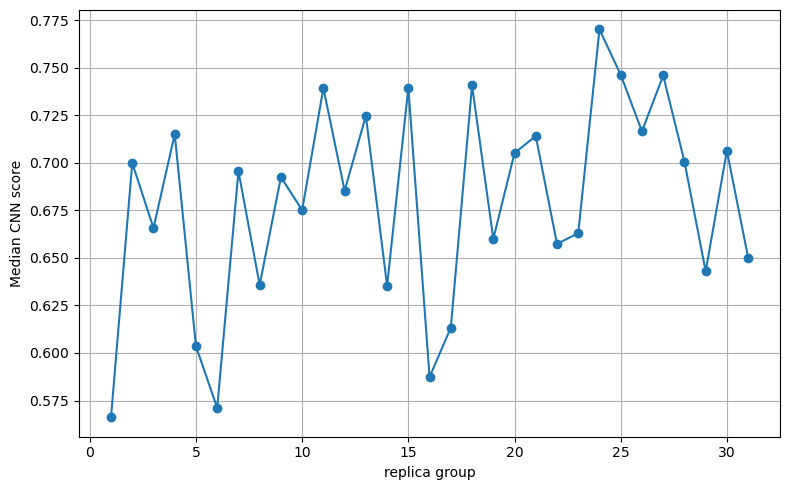

In [61]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [64]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

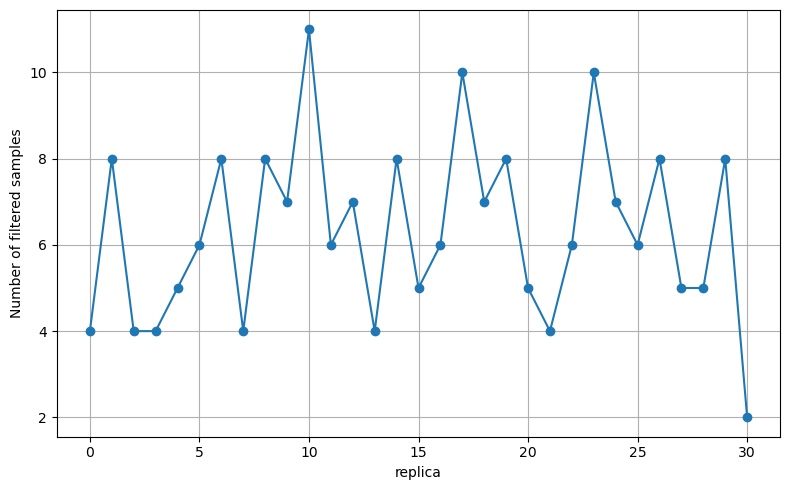

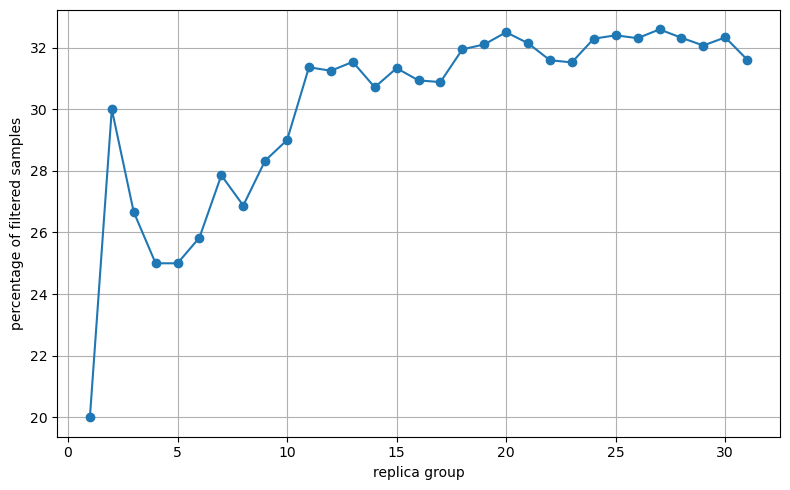

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([20.        , 30.        , 26.66666667, 25.        , 25.        ,
        25.83333333, 27.85714286, 26.875     , 28.33333333, 29.        ,
        31.36363636, 31.25      , 31.53846154, 30.71428571, 31.33333333,
        30.9375    , 30.88235294, 31.94444444, 32.10526316, 32.5       ,
        32.14285714, 31.59090909, 31.52173913, 32.29166667, 32.4       ,
        32.30769231, 32.59259259, 32.32142857, 32.06896552, 32.33333333,
        31.61290323]))

In [65]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

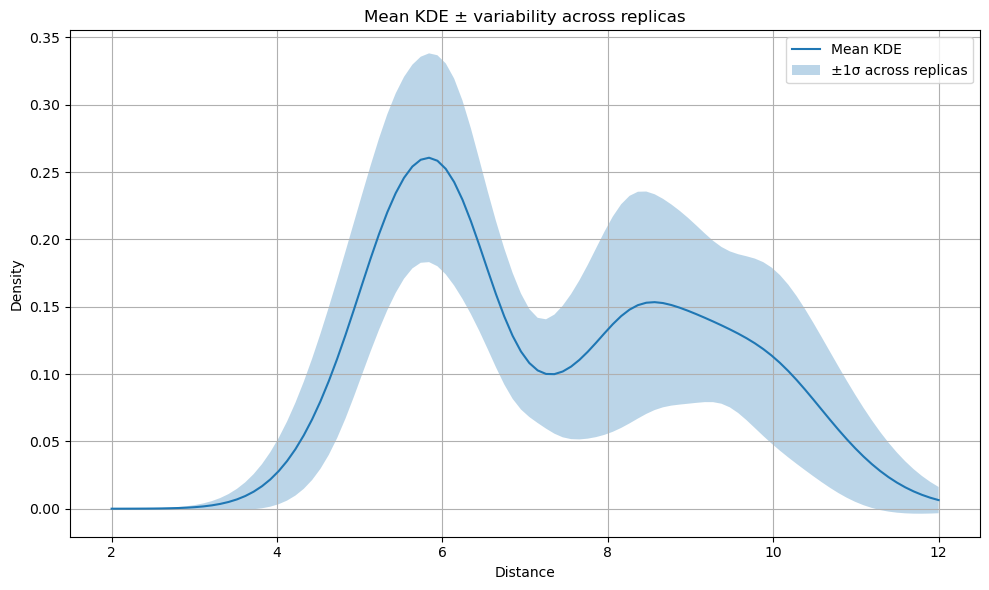

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [66]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|█████████████████████████████████████████████████████████████████| 4000/4000 [00:03<00:00, 1117.51it/s]


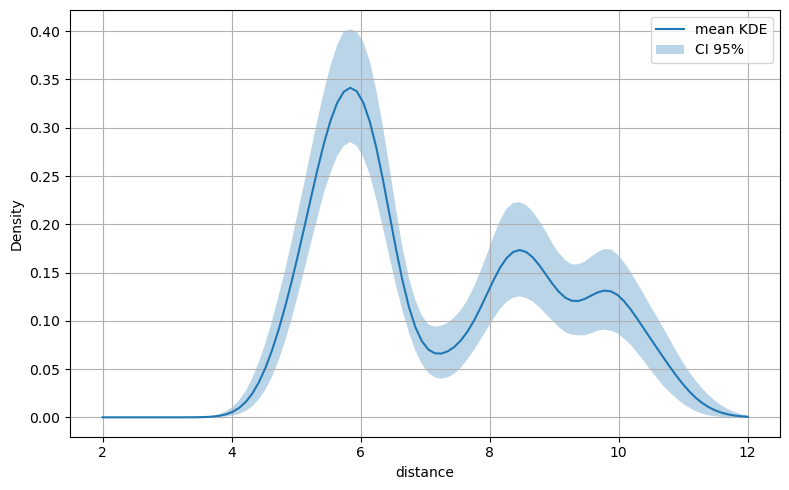

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,3.446681e-13,9.618897e-13,3.103586e-16,2.299261e-12
1,2.10101,2.001862e-12,4.970524e-12,2.817727e-15,1.282793e-11
2,2.20202,1.097000e-11,2.430579e-11,2.247144e-14,6.738514e-11
3,2.30303,5.667758e-11,1.123755e-10,1.796255e-13,3.216373e-10
4,2.40404,2.758948e-10,4.908231e-10,1.321349e-12,1.482960e-09
...,...,...,...,...,...
95,11.59596,4.755844e-03,3.153100e-03,4.754321e-04,1.220664e-02
96,11.69697,3.004572e-03,2.206250e-03,2.012187e-04,8.223869e-03
97,11.79798,1.811937e-03,1.451786e-03,7.918546e-05,5.309907e-03
98,11.89899,1.038473e-03,8.963016e-04,2.842429e-05,3.232286e-03


In [67]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-Glc 

In [68]:
config = AnalysisConfig(
    root="Glc-UDP/conf1",
    substrate_name="UDP-Glc",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 42 and not protein",
    atom_sel_2="id 1356 and protein",
    obrms_exe=r""
)

In [69]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-7.87,-1.49,0.9252,4.394,rep_0,0
1,2.0,-8.16,4.56,0.9123,4.369,rep_0,0
2,3.0,-6.94,-2.05,0.9094,4.471,rep_0,0
3,4.0,-7.45,3.92,0.9092,4.080,rep_0,0
4,5.0,-8.50,-1.15,0.8978,4.392,rep_0,0


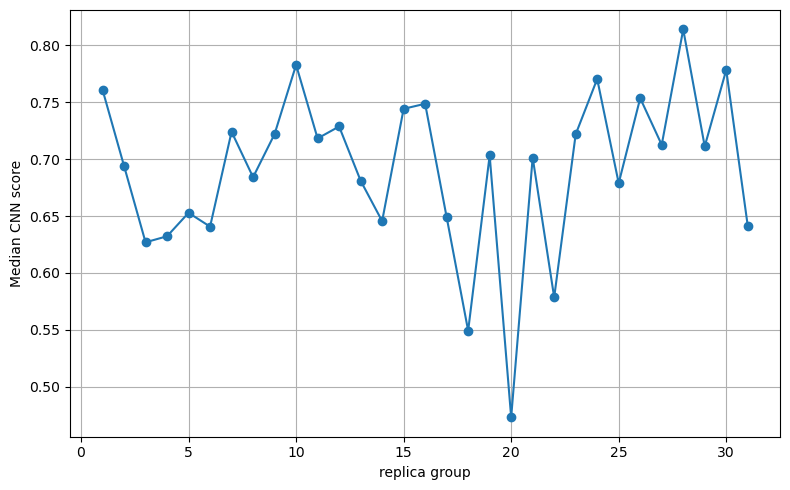

In [70]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [71]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

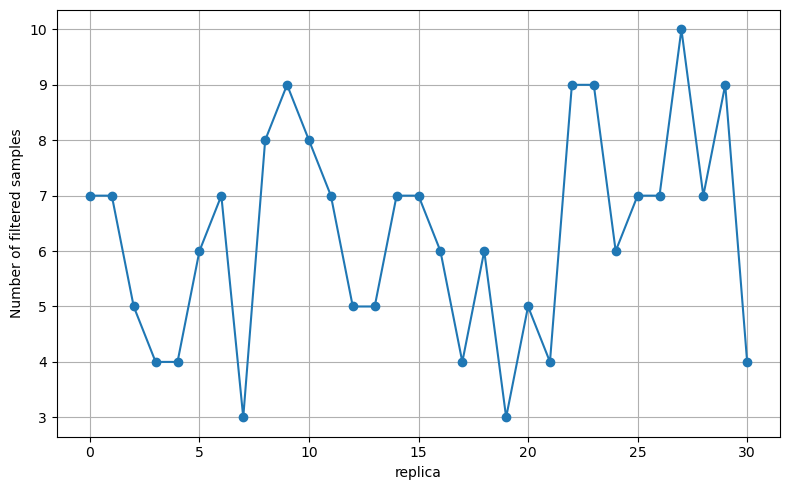

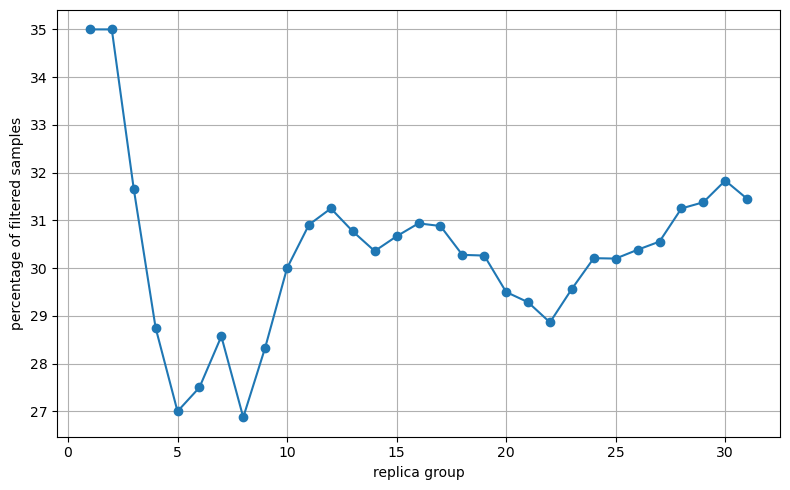

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([35.        , 35.        , 31.66666667, 28.75      , 27.        ,
        27.5       , 28.57142857, 26.875     , 28.33333333, 30.        ,
        30.90909091, 31.25      , 30.76923077, 30.35714286, 30.66666667,
        30.9375    , 30.88235294, 30.27777778, 30.26315789, 29.5       ,
        29.28571429, 28.86363636, 29.56521739, 30.20833333, 30.2       ,
        30.38461538, 30.55555556, 31.25      , 31.37931034, 31.83333333,
        31.4516129 ]))

In [72]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

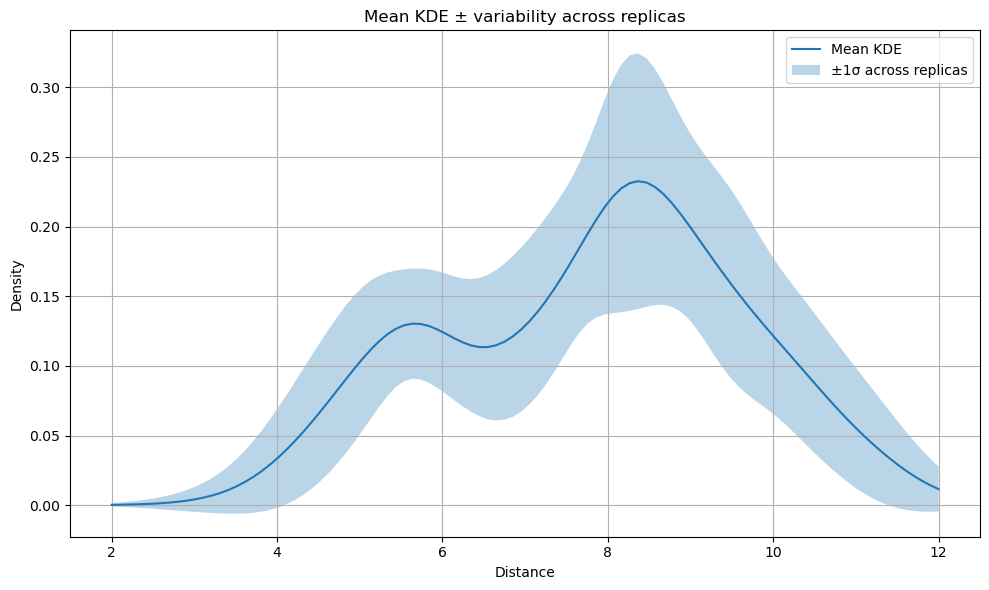

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [73]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|█████████████████████████████████████████████████████████████████| 4000/4000 [00:03<00:00, 1077.46it/s]


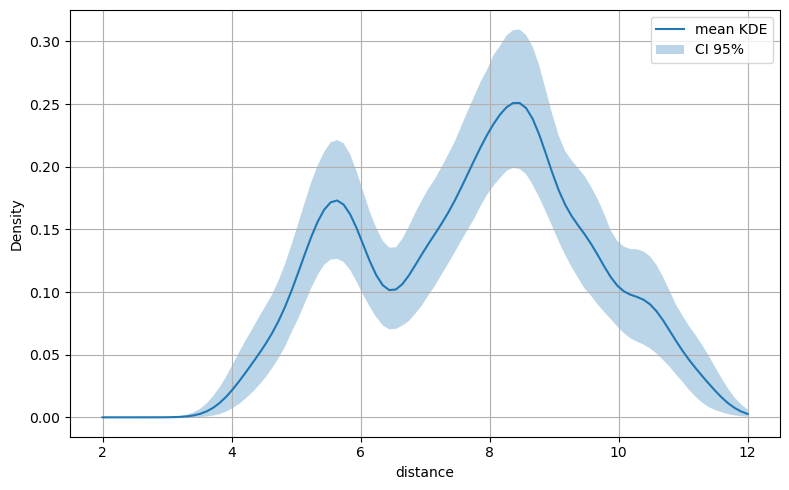

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,4.177193e-10,9.713637e-10,8.674146e-14,2.754312e-09
1,2.10101,1.853665e-09,3.855358e-09,6.742849e-13,1.153800e-08
2,2.20202,7.748102e-09,1.447088e-08,4.662110e-12,4.548606e-08
3,2.30303,3.047732e-08,5.130151e-08,3.150904e-11,1.659130e-07
4,2.40404,1.127157e-07,1.715854e-07,1.858441e-10,5.716488e-07
...,...,...,...,...,...
95,11.59596,1.586666e-02,7.069156e-03,4.027317e-03,3.101365e-02
96,11.69697,1.120857e-02,5.294286e-03,2.534933e-03,2.273889e-02
97,11.79798,7.440861e-03,3.716664e-03,1.515689e-03,1.568656e-02
98,11.89899,4.625961e-03,2.445664e-03,8.262246e-04,1.021755e-02


In [74]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-GlaA 

In [75]:
config = AnalysisConfig(
    root="GlaA-UDP/conf1",
    substrate_name="UDP-GlaA",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 43 and not protein",
    atom_sel_2="id 1356 and protein",
    obrms_exe=r""
)

In [76]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.19,-1.77,0.9252,4.362,rep_0,0
1,2.0,-8.52,-1.56,0.8604,4.301,rep_0,0
2,3.0,-8.06,6.36,0.8254,4.109,rep_0,0
3,4.0,-6.99,-1.82,0.8013,4.441,rep_0,0
4,5.0,-7.22,5.62,0.7783,4.305,rep_0,0


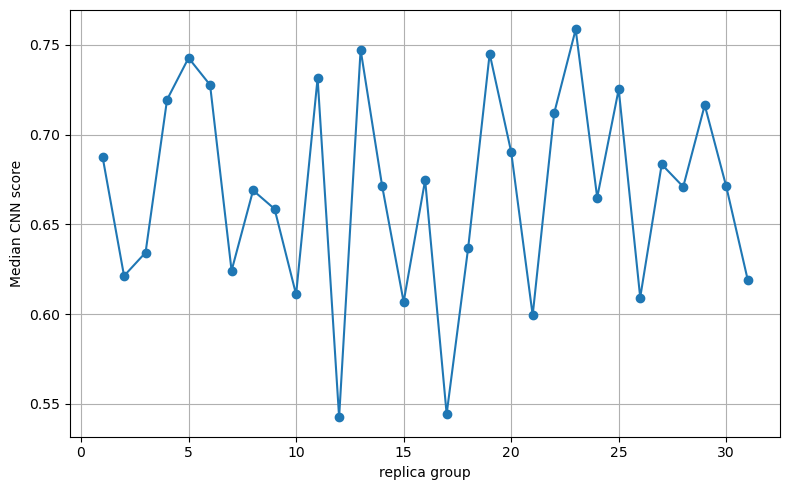

In [77]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [78]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

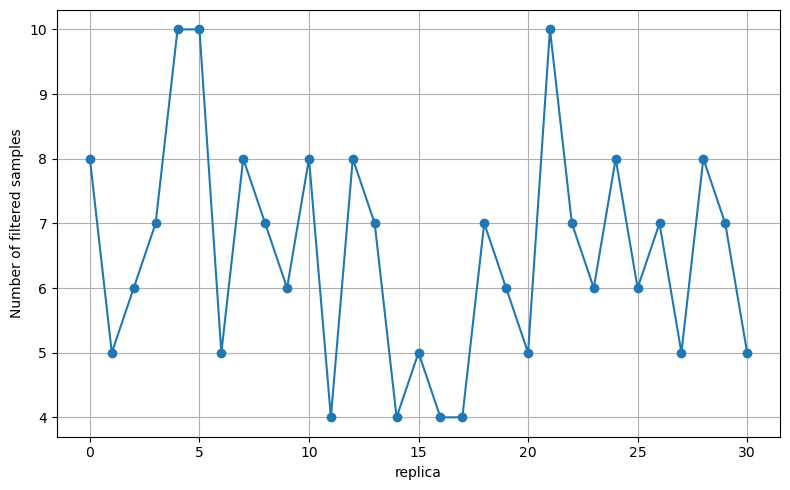

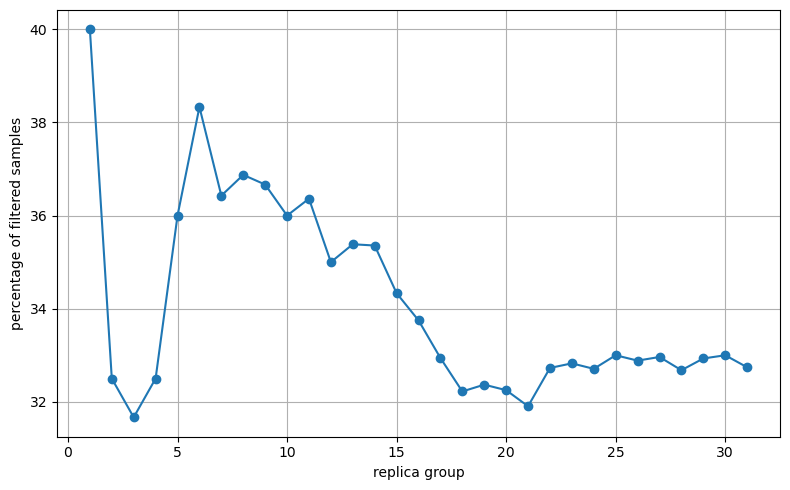

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([40.        , 32.5       , 31.66666667, 32.5       , 36.        ,
        38.33333333, 36.42857143, 36.875     , 36.66666667, 36.        ,
        36.36363636, 35.        , 35.38461538, 35.35714286, 34.33333333,
        33.75      , 32.94117647, 32.22222222, 32.36842105, 32.25      ,
        31.9047619 , 32.72727273, 32.82608696, 32.70833333, 33.        ,
        32.88461538, 32.96296296, 32.67857143, 32.93103448, 33.        ,
        32.74193548]))

In [79]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

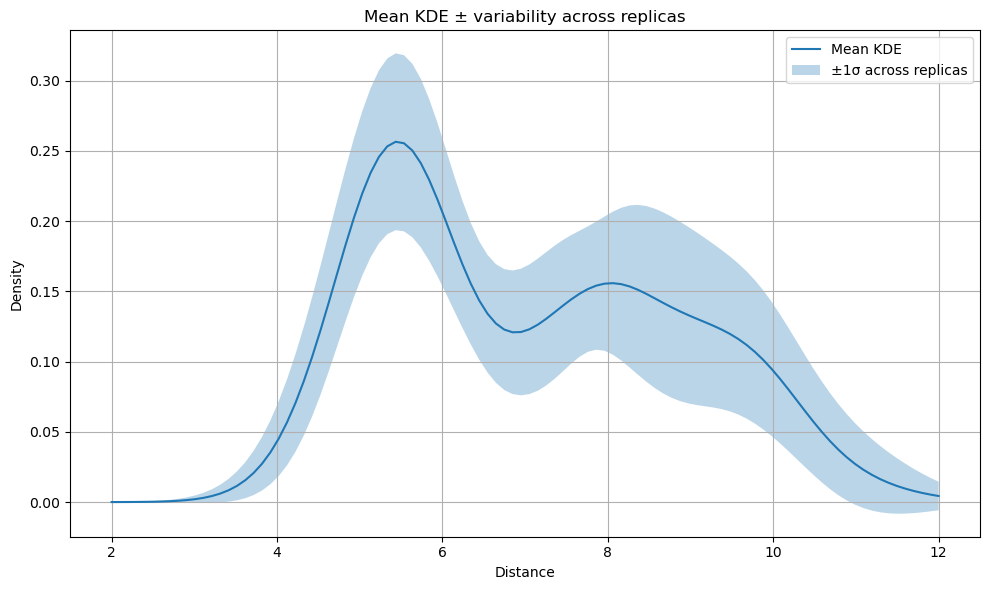

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [80]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|█████████████████████████████████████████████████████████████████| 4000/4000 [00:03<00:00, 1010.07it/s]


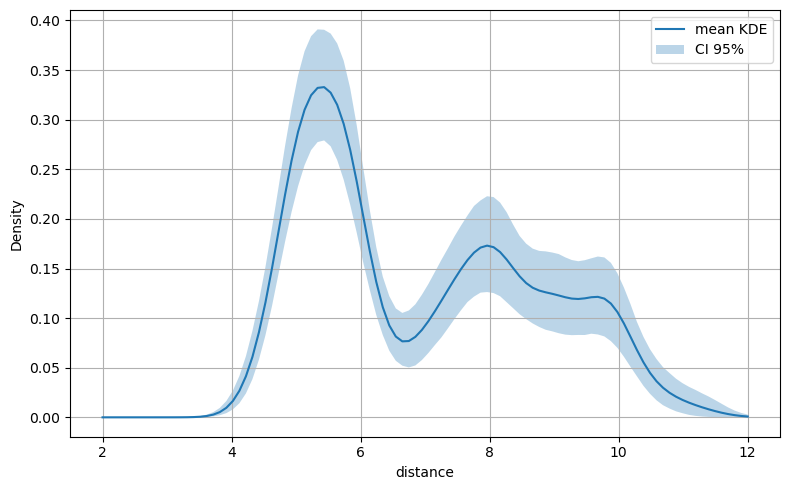

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,2.327013e-12,5.760108e-12,1.462850e-14,1.415226e-11
1,2.10101,1.306284e-11,2.847150e-11,1.259573e-13,7.646567e-11
2,2.20202,6.916566e-11,1.330553e-10,9.783918e-13,3.792071e-10
3,2.30303,3.451245e-10,5.875856e-10,6.932318e-12,1.786796e-09
4,2.40404,1.621496e-09,2.450367e-09,4.585095e-11,7.784173e-09
...,...,...,...,...,...
95,11.59596,4.643315e-03,3.745005e-03,8.423102e-05,1.363389e-02
96,11.69697,3.277644e-03,2.816822e-03,3.375295e-05,9.937855e-03
97,11.79798,2.189238e-03,1.982399e-03,1.223669e-05,6.799105e-03
98,11.89899,1.377522e-03,1.303948e-03,4.186679e-06,4.427265e-03


In [81]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-Gla 

In [82]:
config = AnalysisConfig(
    root="Gla-UDP/conf1",
    substrate_name="UDP-Gla",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 41 and not protein",
    atom_sel_2="id 1356 and protein",
    obrms_exe=r""
)

In [83]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.02,-0.40,0.9360,4.261,rep_0,0
1,2.0,-8.44,-0.71,0.9289,4.120,rep_0,0
2,3.0,-8.00,-0.82,0.9260,4.641,rep_0,0
3,4.0,-7.40,-0.69,0.9232,4.147,rep_0,0
4,5.0,-7.46,-0.41,0.8266,4.197,rep_0,0


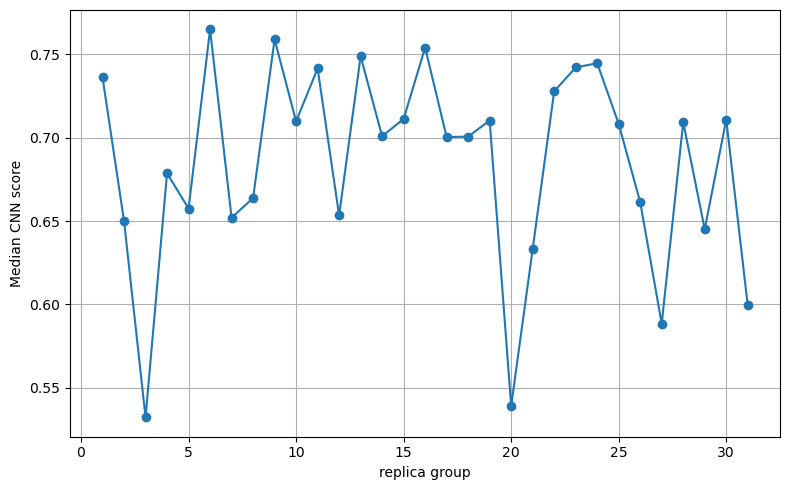

In [84]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [85]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

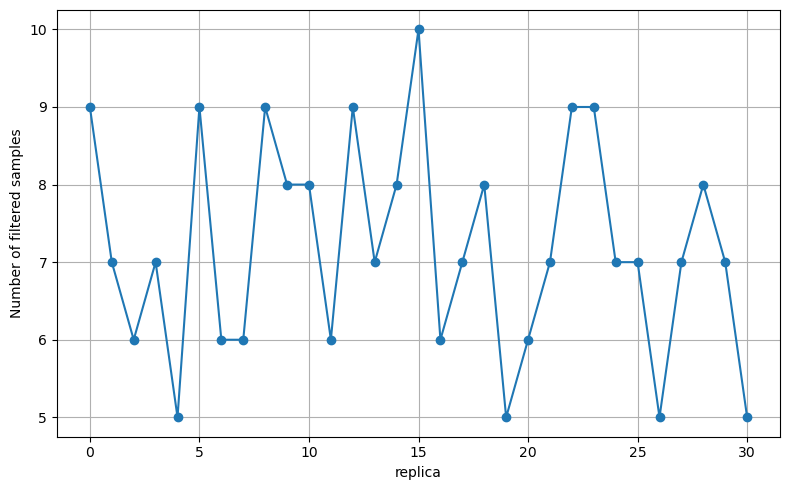

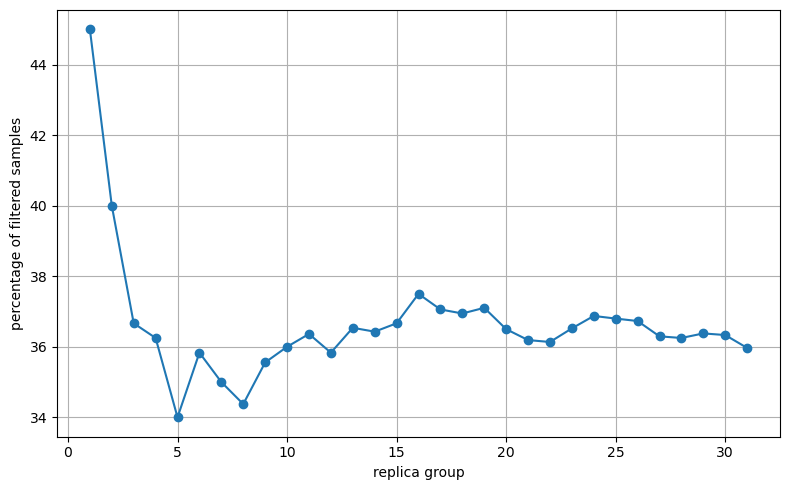

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([45.        , 40.        , 36.66666667, 36.25      , 34.        ,
        35.83333333, 35.        , 34.375     , 35.55555556, 36.        ,
        36.36363636, 35.83333333, 36.53846154, 36.42857143, 36.66666667,
        37.5       , 37.05882353, 36.94444444, 37.10526316, 36.5       ,
        36.19047619, 36.13636364, 36.52173913, 36.875     , 36.8       ,
        36.73076923, 36.2962963 , 36.25      , 36.37931034, 36.33333333,
        35.96774194]))

In [86]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

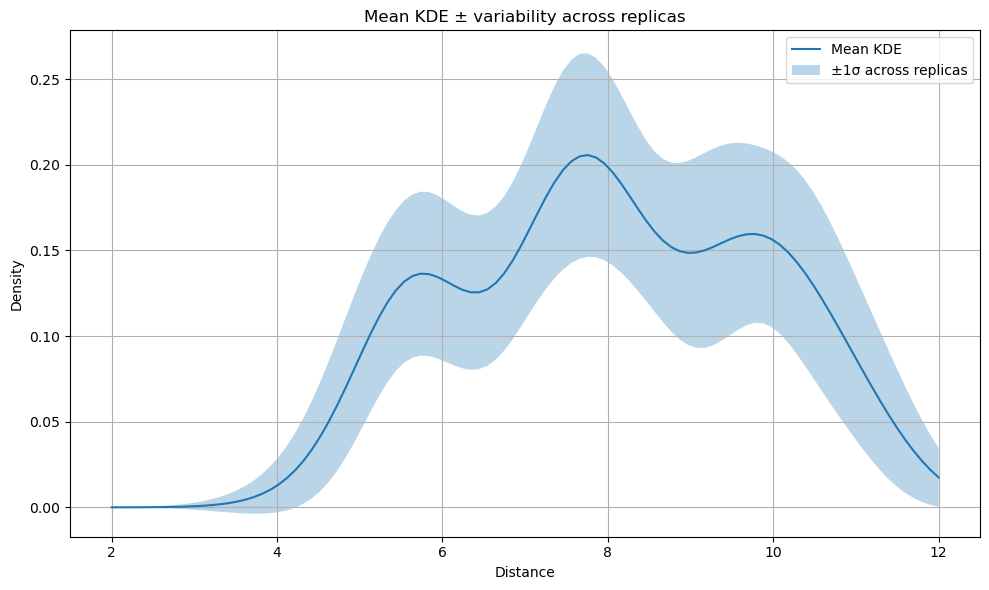

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [87]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|██████████████████████████████████████████████████████████████████| 4000/4000 [00:04<00:00, 863.06it/s]


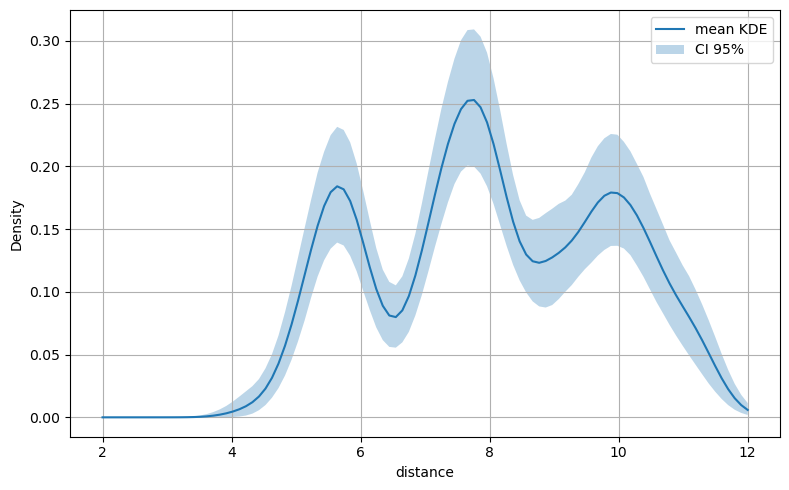

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,1.553225e-11,3.843418e-11,2.910644e-19,1.023786e-10
1,2.10101,7.769881e-11,1.749235e-10,3.609608e-18,4.844186e-10
2,2.20202,3.648349e-10,7.508196e-10,4.162068e-17,2.235582e-09
3,2.30303,1.606614e-09,3.037160e-09,4.320768e-16,9.384740e-09
4,2.40404,6.629701e-09,1.156965e-08,3.975957e-15,3.617893e-08
...,...,...,...,...,...
95,11.59596,3.114527e-02,9.294393e-03,1.462924e-02,5.055434e-02
96,11.69697,2.242384e-02,7.284536e-03,9.735273e-03,3.778231e-02
97,11.79798,1.523818e-02,5.387765e-03,6.039282e-03,2.669222e-02
98,11.89899,9.747328e-03,3.747589e-03,3.507935e-03,1.794651e-02


In [88]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-NGlu 

In [89]:
config = AnalysisConfig(
    root="NGlu-UDP/conf1",
    substrate_name="UDP-NGlu",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 44 and not protein",
    atom_sel_2="id 1356 and protein",
    obrms_exe=r""
)

In [90]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-7.96,-0.25,0.9382,4.729,rep_0,0
1,2.0,-7.90,-0.54,0.9100,4.659,rep_0,0
2,3.0,-7.62,-1.23,0.8503,4.448,rep_0,0
3,4.0,-7.73,0.65,0.8165,3.987,rep_0,0
4,5.0,-7.63,0.38,0.7780,4.277,rep_0,0


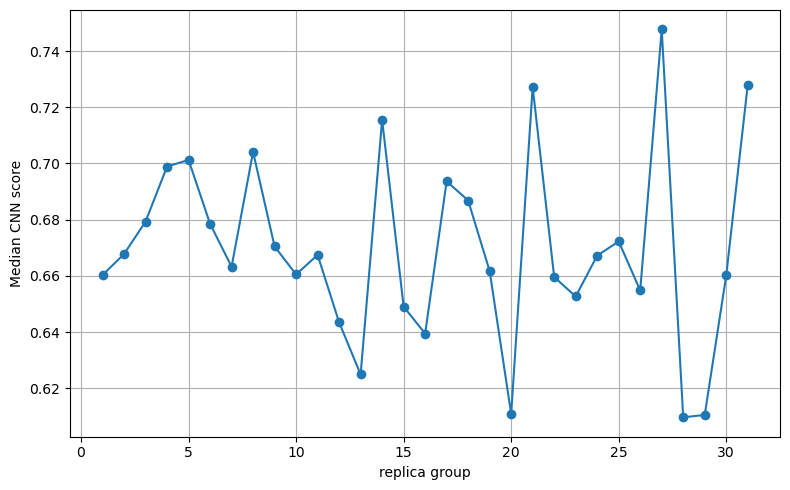

In [91]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [92]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

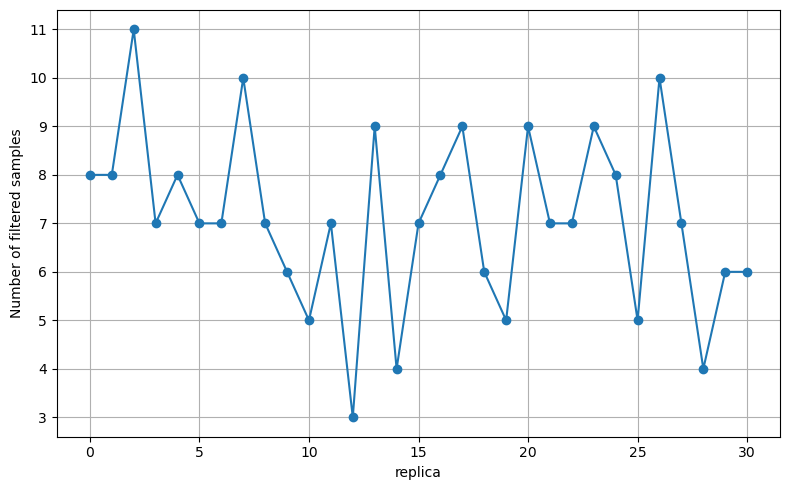

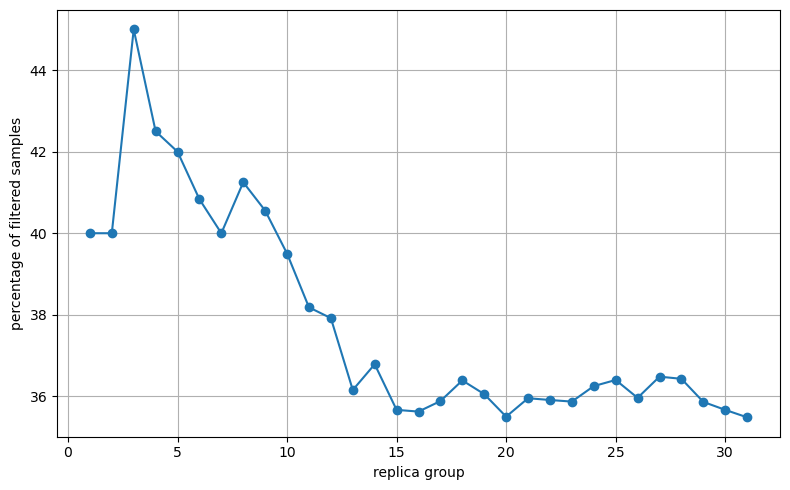

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([40.        , 40.        , 45.        , 42.5       , 42.        ,
        40.83333333, 40.        , 41.25      , 40.55555556, 39.5       ,
        38.18181818, 37.91666667, 36.15384615, 36.78571429, 35.66666667,
        35.625     , 35.88235294, 36.38888889, 36.05263158, 35.5       ,
        35.95238095, 35.90909091, 35.86956522, 36.25      , 36.4       ,
        35.96153846, 36.48148148, 36.42857143, 35.86206897, 35.66666667,
        35.48387097]))

In [93]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

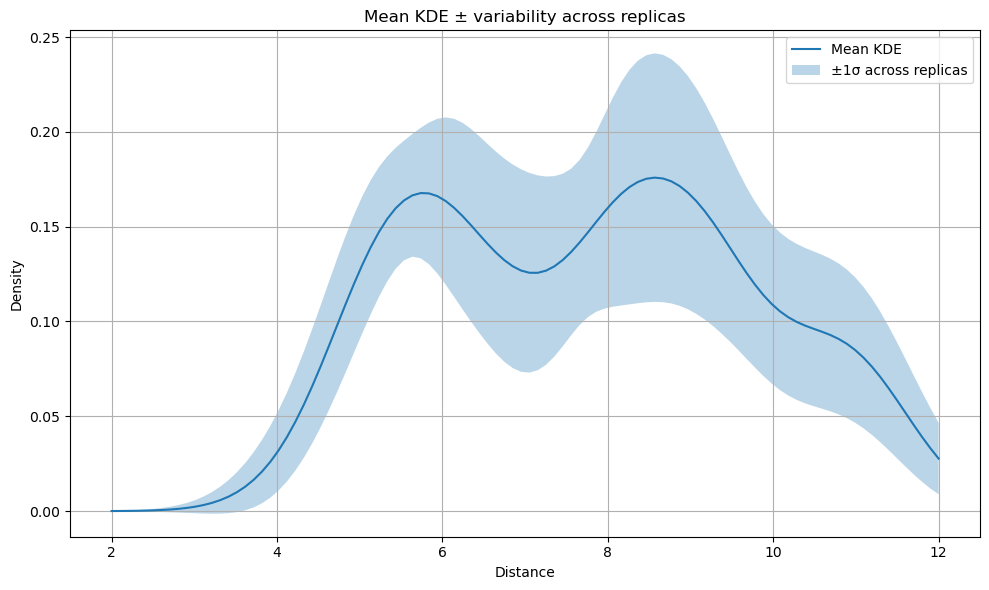

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [94]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|██████████████████████████████████████████████████████████████████| 4000/4000 [00:05<00:00, 704.78it/s]


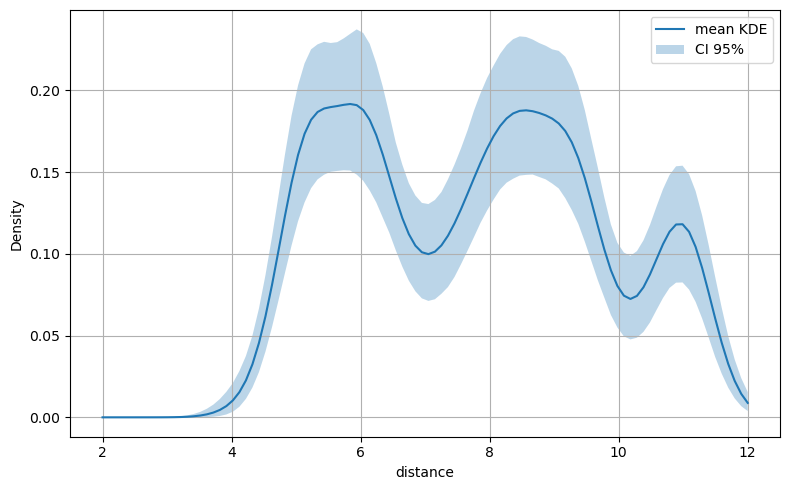

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,1.127422e-09,2.082996e-09,1.651209e-14,6.455489e-09
1,2.10101,4.195445e-09,7.188164e-09,1.150960e-13,2.336353e-08
2,2.20202,1.477371e-08,2.360602e-08,7.470867e-13,7.965649e-08
3,2.30303,4.919959e-08,7.370722e-08,4.554967e-12,2.526382e-07
4,2.40404,1.548651e-07,2.186387e-07,2.550209e-11,7.624408e-07
...,...,...,...,...,...
95,11.59596,4.571929e-02,1.015234e-02,2.675842e-02,6.716020e-02
96,11.69697,3.275449e-02,8.008406e-03,1.819204e-02,4.979898e-02
97,11.79798,2.227423e-02,6.037507e-03,1.156166e-02,3.537474e-02
98,11.89899,1.437595e-02,4.344207e-03,6.837636e-03,2.401264e-02


In [95]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-NGla 

In [96]:
config = AnalysisConfig(
    root="NGla-UDP/conf1",
    substrate_name="UDP-NGla",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 44 and not protein",
    atom_sel_2="id 1356 and protein",
    obrms_exe=r""
)

In [97]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.04,-2.23,0.8708,4.435,rep_0,0
1,2.0,-8.04,-2.03,0.8493,5.338,rep_0,0
2,3.0,-6.75,0.11,0.7502,4.401,rep_0,0
3,4.0,-6.81,-2.00,0.7346,5.385,rep_0,0
4,5.0,-7.58,6.27,0.7113,4.096,rep_0,0


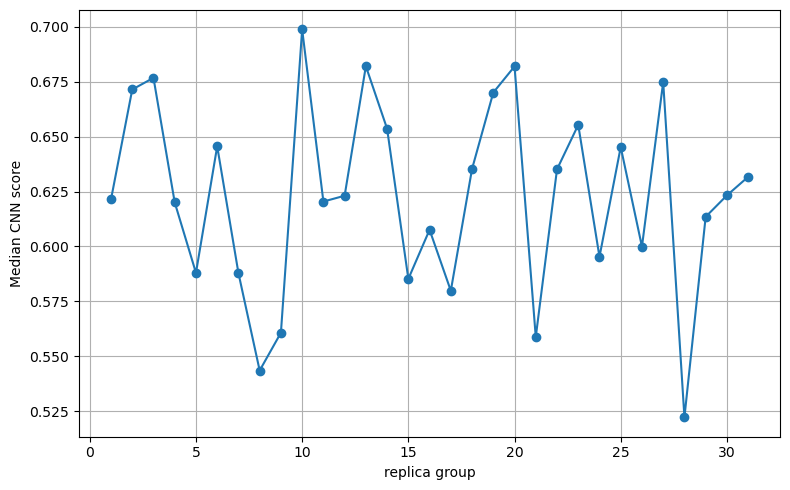

In [98]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [99]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

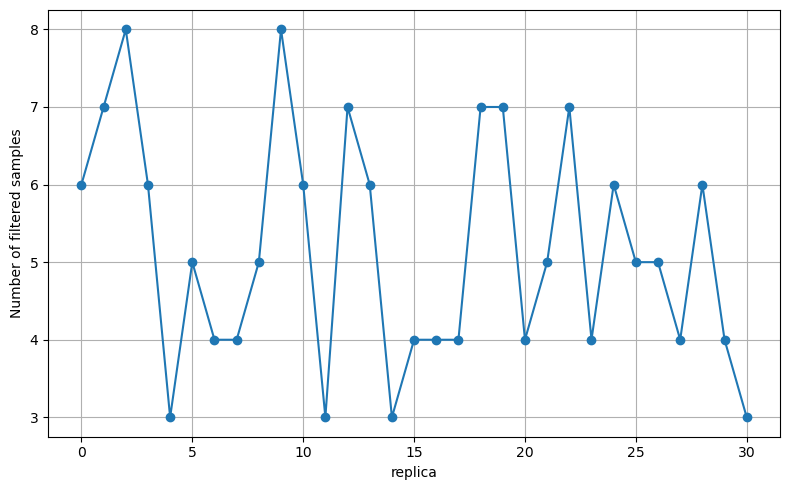

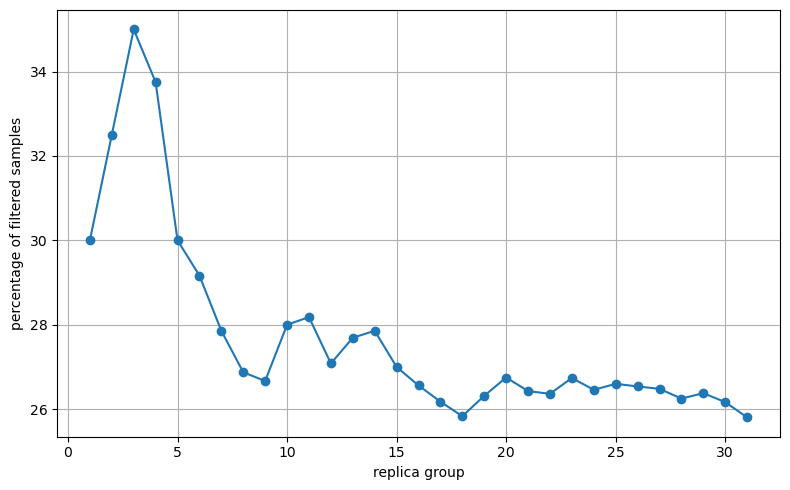

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([30.        , 32.5       , 35.        , 33.75      , 30.        ,
        29.16666667, 27.85714286, 26.875     , 26.66666667, 28.        ,
        28.18181818, 27.08333333, 27.69230769, 27.85714286, 27.        ,
        26.5625    , 26.17647059, 25.83333333, 26.31578947, 26.75      ,
        26.42857143, 26.36363636, 26.73913043, 26.45833333, 26.6       ,
        26.53846154, 26.48148148, 26.25      , 26.37931034, 26.16666667,
        25.80645161]))

In [100]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

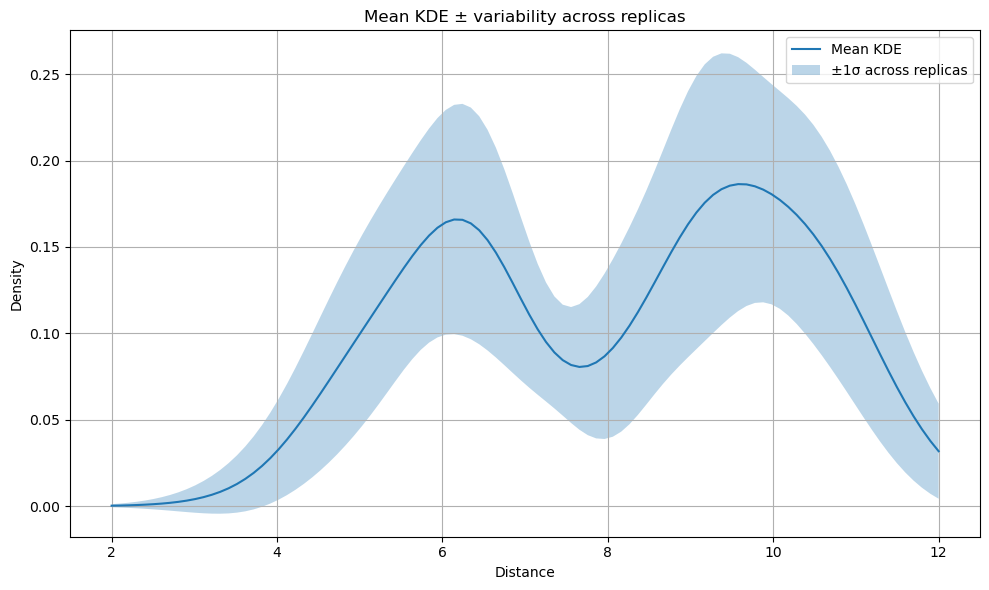

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [101]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|██████████████████████████████████████████████████████████████████| 4000/4000 [00:04<00:00, 831.24it/s]


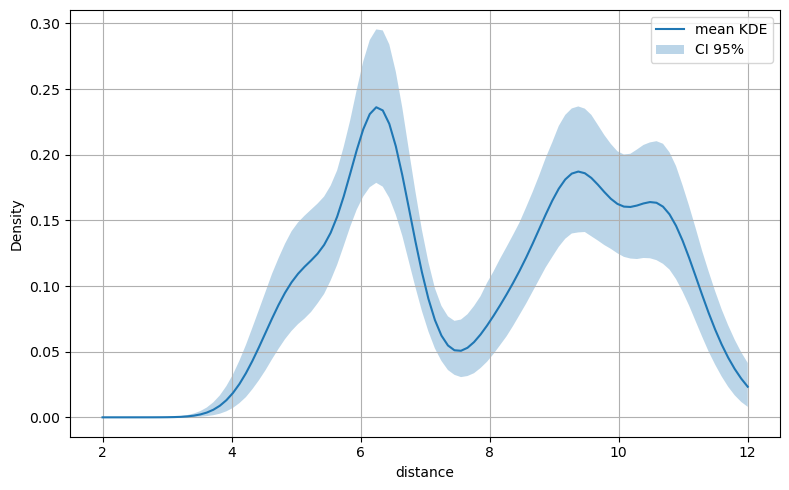

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,7.889745e-09,1.213291e-08,6.622179e-11,4.074311e-08
1,2.10101,2.433760e-08,3.464623e-08,2.724885e-10,1.196876e-07
2,2.20202,7.205920e-08,9.507478e-08,1.053539e-09,3.344358e-07
3,2.30303,2.047394e-07,2.506437e-07,3.966070e-09,8.896508e-07
4,2.40404,5.581181e-07,6.345989e-07,1.402615e-08,2.260197e-06
...,...,...,...,...,...
95,11.59596,5.546143e-02,1.317798e-02,3.109739e-02,8.221041e-02
96,11.69697,4.546389e-02,1.200791e-02,2.326934e-02,7.004672e-02
97,11.79798,3.684323e-02,1.085999e-02,1.677136e-02,5.912544e-02
98,11.89899,2.949601e-02,9.716929e-03,1.171715e-02,4.957036e-02


In [102]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

## con0

### UDP-GlcA 

In [109]:
config = AnalysisConfig(
    root="GlcA-UDP/conf0",
    protein_pdb = "WTB.pdb",
    substrate_name="UDP-GlcA",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 43 and not protein",
    atom_sel_2="id 1269 and protein",
    obrms_exe=r""
)

In [110]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.54,-1.55,0.9260,4.965,rep_0,0
1,2.0,-8.63,-1.14,0.8971,4.026,rep_0,0
2,3.0,-8.41,-1.74,0.8847,4.794,rep_0,0
3,4.0,-8.58,-1.34,0.8231,4.155,rep_0,0
4,5.0,-6.83,-1.45,0.8021,4.874,rep_0,0


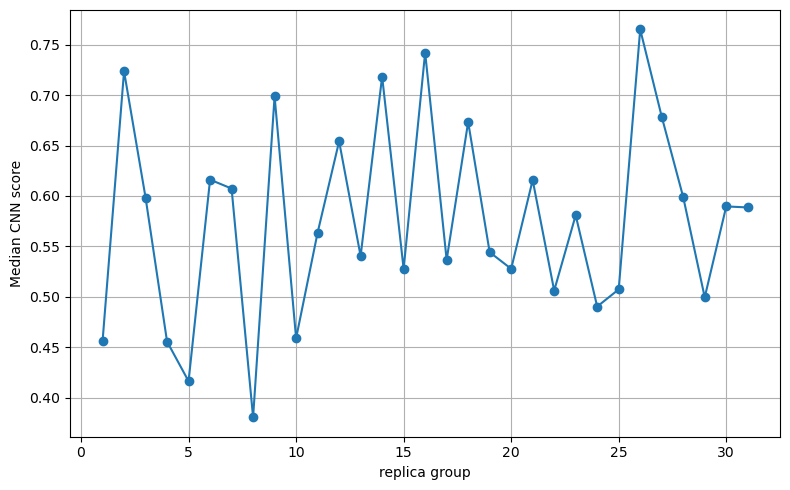

In [111]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [112]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

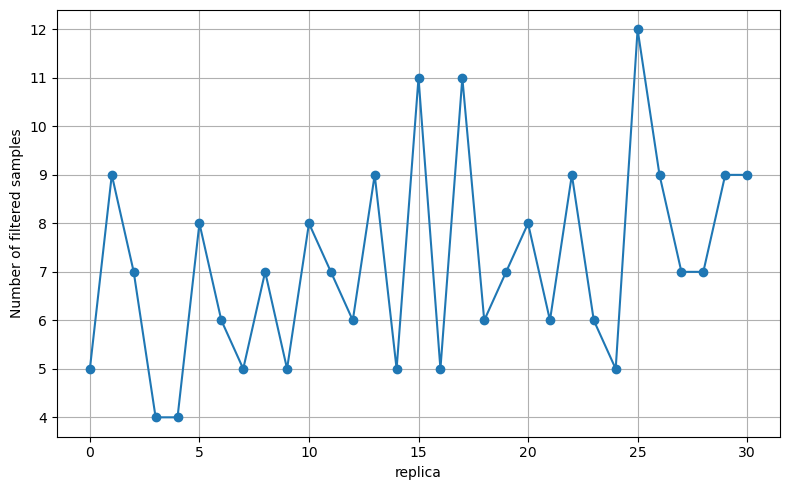

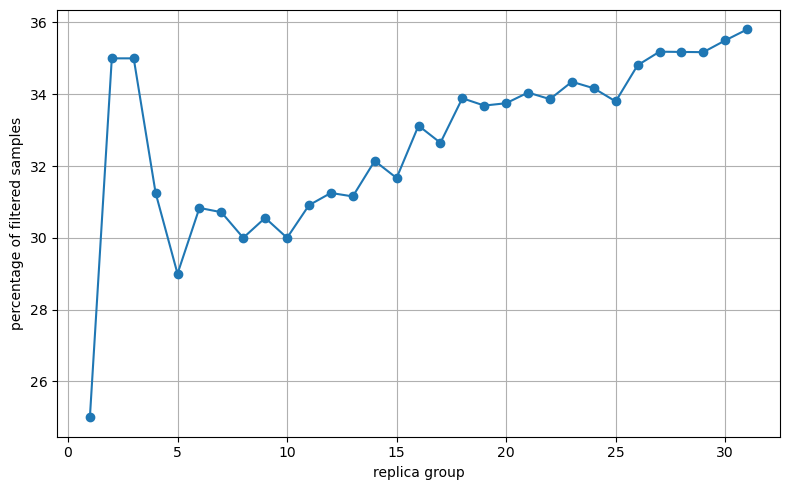

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([25.        , 35.        , 35.        , 31.25      , 29.        ,
        30.83333333, 30.71428571, 30.        , 30.55555556, 30.        ,
        30.90909091, 31.25      , 31.15384615, 32.14285714, 31.66666667,
        33.125     , 32.64705882, 33.88888889, 33.68421053, 33.75      ,
        34.04761905, 33.86363636, 34.34782609, 34.16666667, 33.8       ,
        34.80769231, 35.18518519, 35.17857143, 35.17241379, 35.5       ,
        35.80645161]))

In [113]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

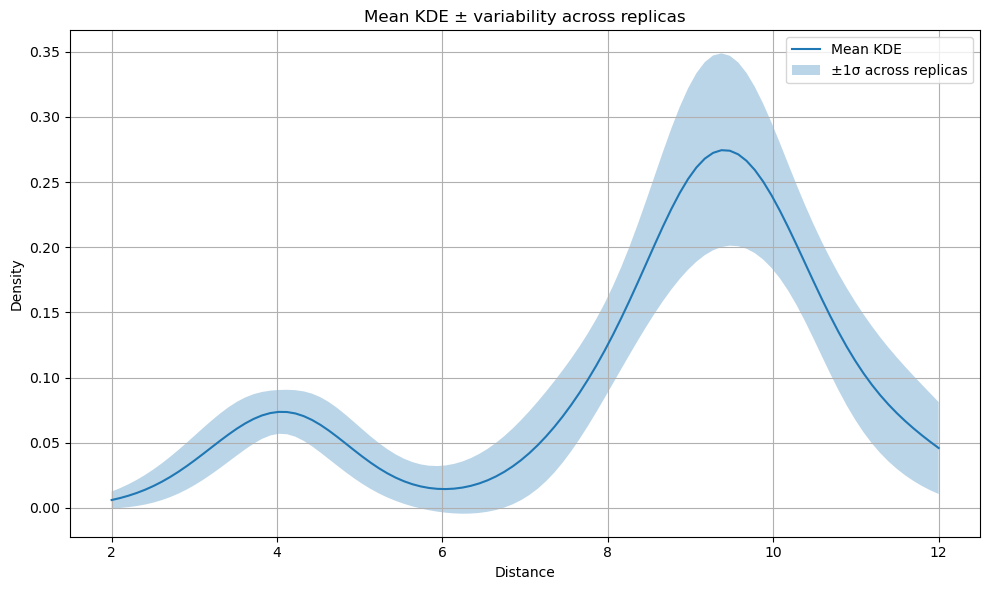

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [114]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|██████████████████████████████████████████████████████████████████| 4000/4000 [00:05<00:00, 747.27it/s]


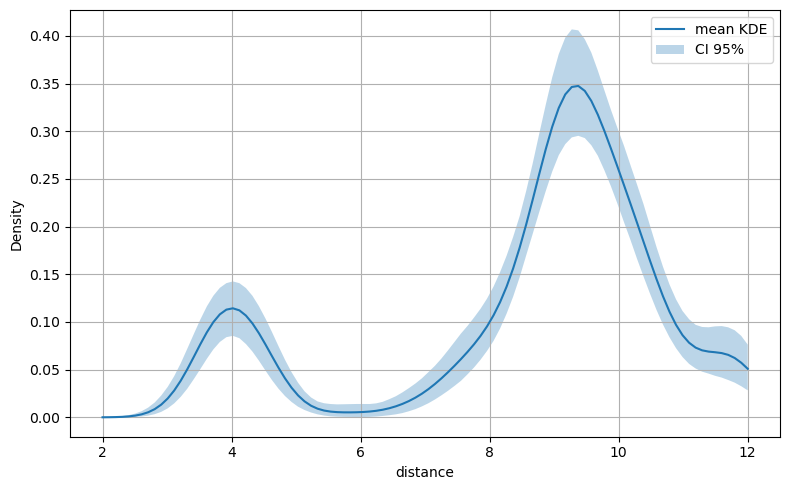

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,0.000057,0.000049,0.000005,0.000181
1,2.10101,0.000123,0.000096,0.000013,0.000362
2,2.20202,0.000255,0.000181,0.000034,0.000694
3,2.30303,0.000508,0.000325,0.000084,0.001287
4,2.40404,0.000972,0.000559,0.000198,0.002297
...,...,...,...,...,...
95,11.59596,0.067359,0.013720,0.041680,0.095674
96,11.69697,0.065509,0.014033,0.039139,0.094395
97,11.79798,0.062201,0.013912,0.036366,0.091297
98,11.89899,0.057267,0.013287,0.032619,0.085398


In [115]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-Glu 

In [116]:
config = AnalysisConfig(
    root="Glc-UDP/conf0",
    protein_pdb = "WTB.pdb",
    substrate_name="UDP-Glc",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 42 and not protein",
    atom_sel_2="id 1269 and protein",
    obrms_exe=r""
)

In [117]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.40,-2.02,0.9479,5.411,rep_0,0
1,2.0,-8.46,-1.81,0.9261,5.034,rep_0,0
2,3.0,-7.97,-1.42,0.9035,4.937,rep_0,0
3,4.0,-7.65,-1.45,0.8747,4.544,rep_0,0
4,5.0,-8.13,-2.70,0.8652,4.461,rep_0,0


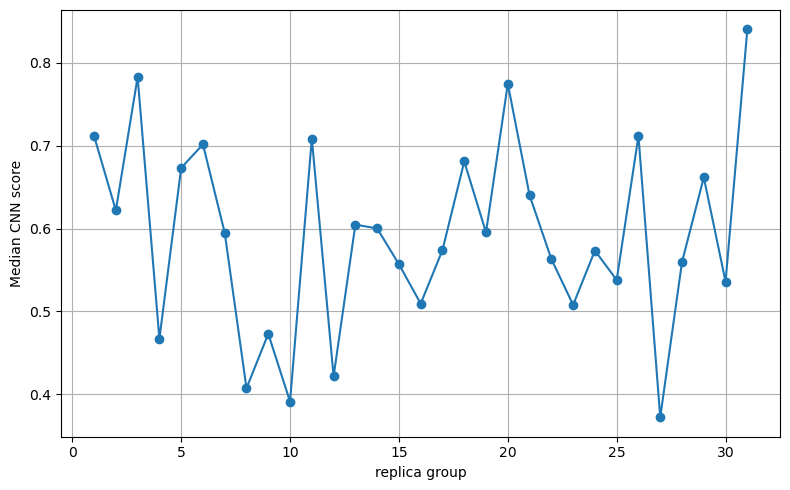

In [118]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [119]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

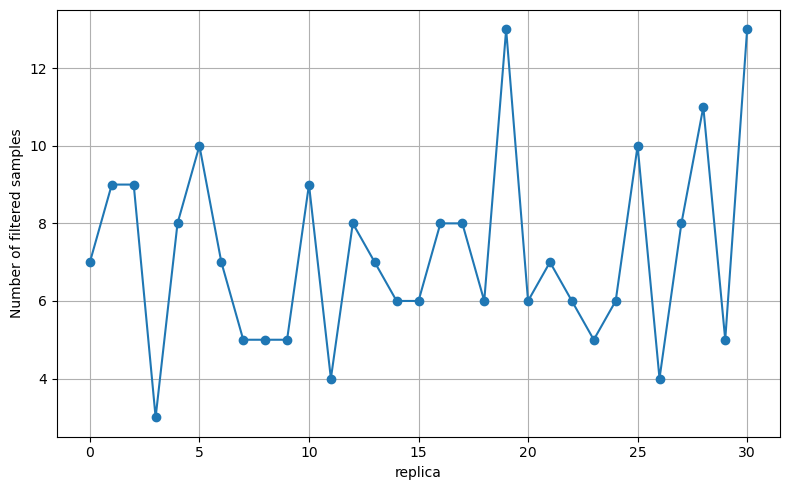

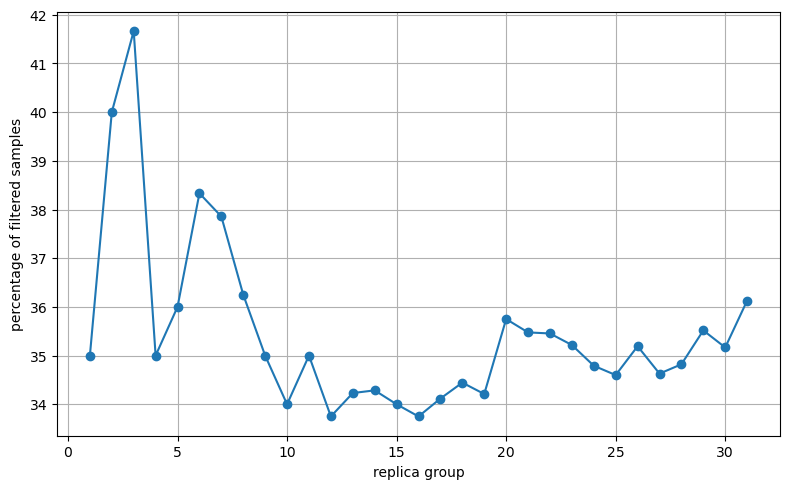

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([35.        , 40.        , 41.66666667, 35.        , 36.        ,
        38.33333333, 37.85714286, 36.25      , 35.        , 34.        ,
        35.        , 33.75      , 34.23076923, 34.28571429, 34.        ,
        33.75      , 34.11764706, 34.44444444, 34.21052632, 35.75      ,
        35.47619048, 35.45454545, 35.2173913 , 34.79166667, 34.6       ,
        35.19230769, 34.62962963, 34.82142857, 35.51724138, 35.16666667,
        36.12903226]))

In [120]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

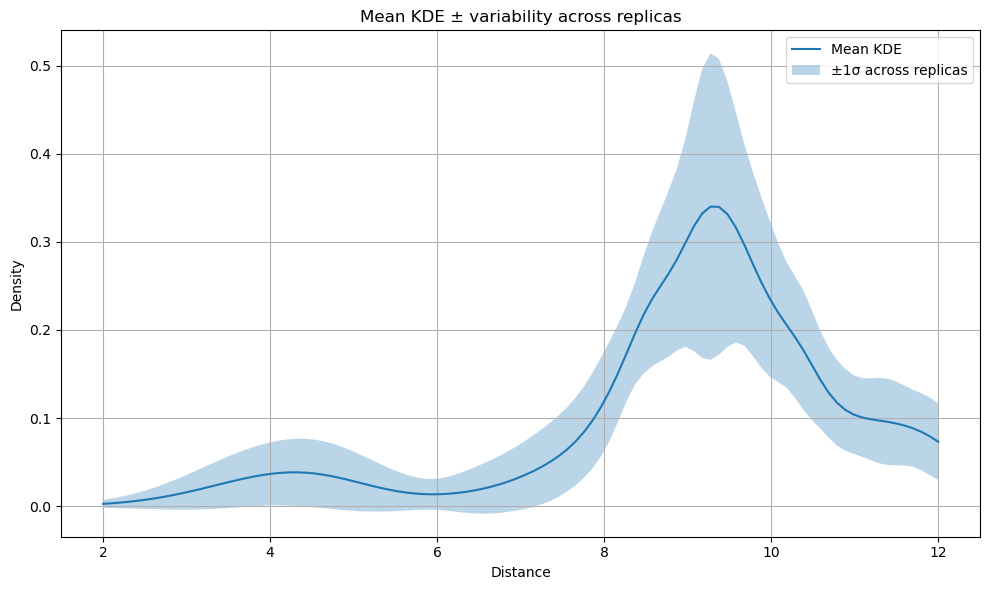

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [121]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|██████████████████████████████████████████████████████████████████| 4000/4000 [00:05<00:00, 703.57it/s]


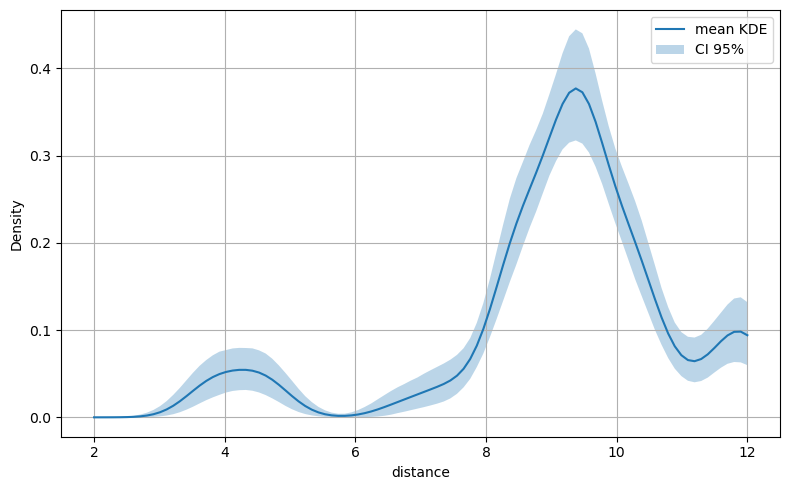

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,0.000004,0.000006,1.812812e-08,0.000019
1,2.10101,0.000009,0.000013,8.079856e-08,0.000046
2,2.20202,0.000024,0.000030,3.340901e-07,0.000106
3,2.30303,0.000057,0.000063,1.255117e-06,0.000232
4,2.40404,0.000129,0.000129,4.310203e-06,0.000484
...,...,...,...,...,...
95,11.59596,0.087151,0.016015,5.684853e-02,0.119932
96,11.69697,0.093853,0.017302,6.136353e-02,0.129245
97,11.79798,0.097958,0.018373,6.339232e-02,0.136165
98,11.89899,0.098223,0.018798,6.295730e-02,0.137520


In [122]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-GlaA 

In [123]:
config = AnalysisConfig(
    root="GlaA-UDP/conf0",
    protein_pdb = "WTB.pdb",
    substrate_name="UDP-GlaA",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 43 and not protein",
    atom_sel_2="id 1269 and protein",
    obrms_exe=r""
)

In [124]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.94,-1.58,0.9410,4.533,rep_0,0
1,2.0,-8.74,-1.63,0.9375,5.326,rep_0,0
2,3.0,-8.50,-1.73,0.8998,4.754,rep_0,0
3,4.0,-8.43,-1.95,0.8864,4.163,rep_0,0
4,5.0,-7.32,-2.41,0.8611,4.328,rep_0,0


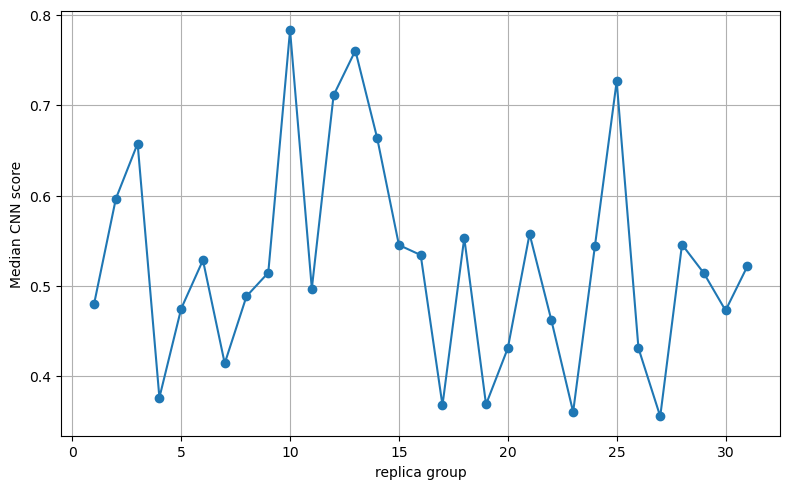

In [125]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [126]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

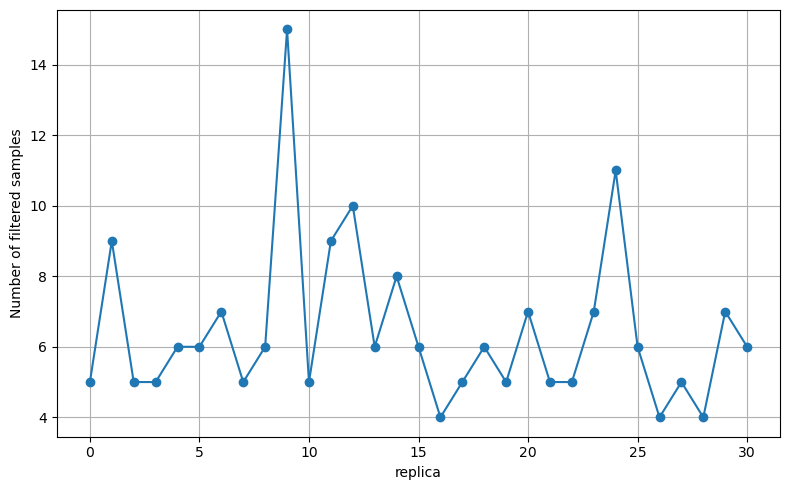

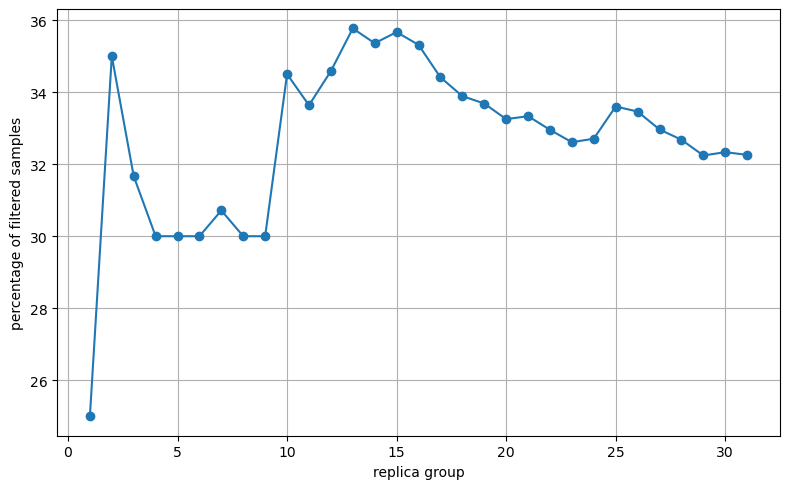

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([25.        , 35.        , 31.66666667, 30.        , 30.        ,
        30.        , 30.71428571, 30.        , 30.        , 34.5       ,
        33.63636364, 34.58333333, 35.76923077, 35.35714286, 35.66666667,
        35.3125    , 34.41176471, 33.88888889, 33.68421053, 33.25      ,
        33.33333333, 32.95454545, 32.60869565, 32.70833333, 33.6       ,
        33.46153846, 32.96296296, 32.67857143, 32.24137931, 32.33333333,
        32.25806452]))

In [127]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

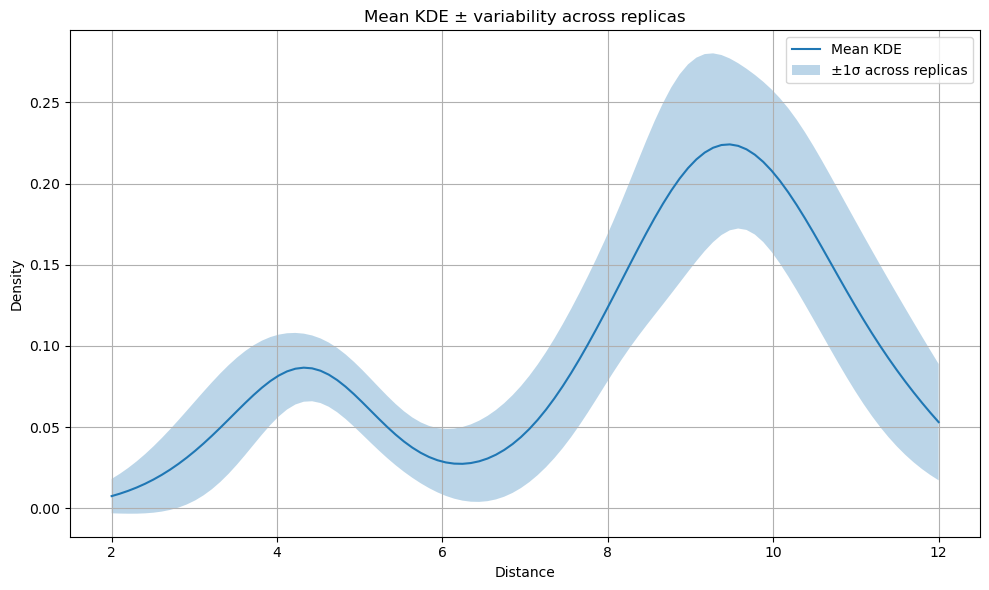

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [128]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|██████████████████████████████████████████████████████████████████| 4000/4000 [00:06<00:00, 662.70it/s]


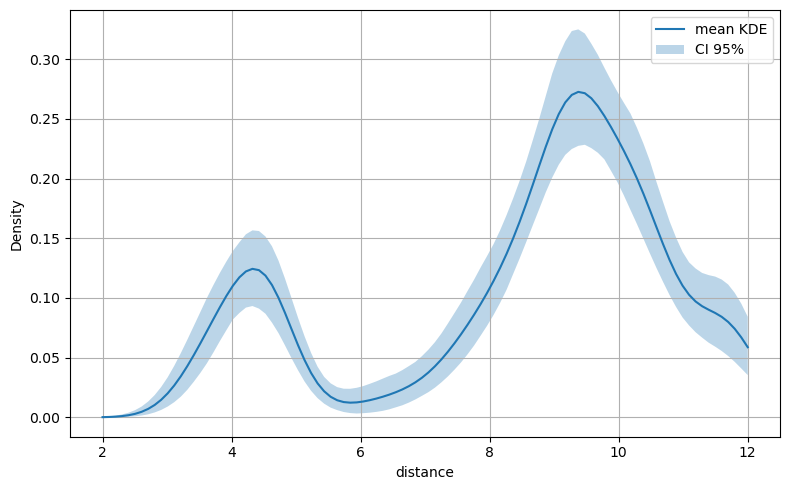

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,0.000176,0.000120,0.000026,0.000478
1,2.10101,0.000333,0.000209,0.000059,0.000845
2,2.20202,0.000607,0.000351,0.000126,0.001459
3,2.30303,0.001067,0.000569,0.000252,0.002439
4,2.40404,0.001808,0.000890,0.000481,0.003909
...,...,...,...,...,...
95,11.59596,0.084204,0.015512,0.055596,0.115446
96,11.69697,0.079896,0.015528,0.051379,0.111248
97,11.79798,0.074178,0.015087,0.046498,0.104290
98,11.89899,0.067036,0.014173,0.041015,0.095290


In [129]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-Gla 

In [130]:
config = AnalysisConfig(
    root="Gla-UDP/conf0",
    protein_pdb = "WTB.pdb",
    substrate_name="UDP-Gla",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 41 and not protein",
    atom_sel_2="id 1269 and protein",
    obrms_exe=r""
)

In [131]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.28,-0.81,0.9631,4.753,rep_0,0
1,2.0,-7.44,-1.43,0.9180,3.834,rep_0,0
2,3.0,-7.22,-0.37,0.9043,4.077,rep_0,0
3,4.0,-8.09,-0.15,0.8941,4.567,rep_0,0
4,5.0,-7.48,0.70,0.8346,4.275,rep_0,0


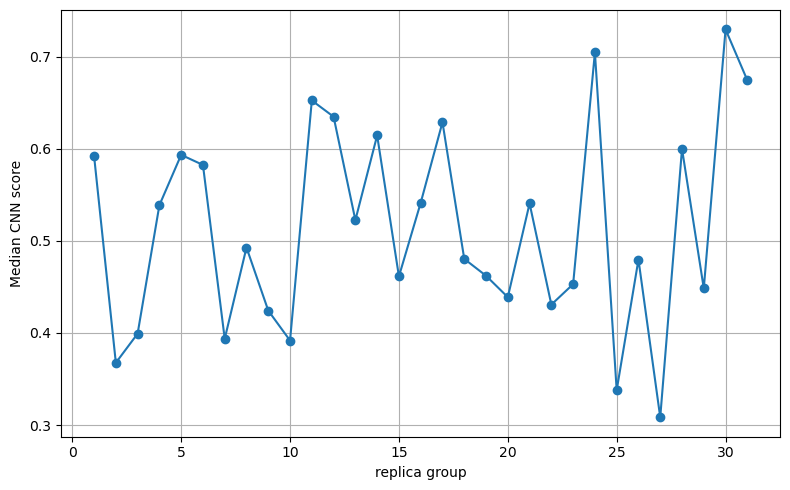

In [132]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [133]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

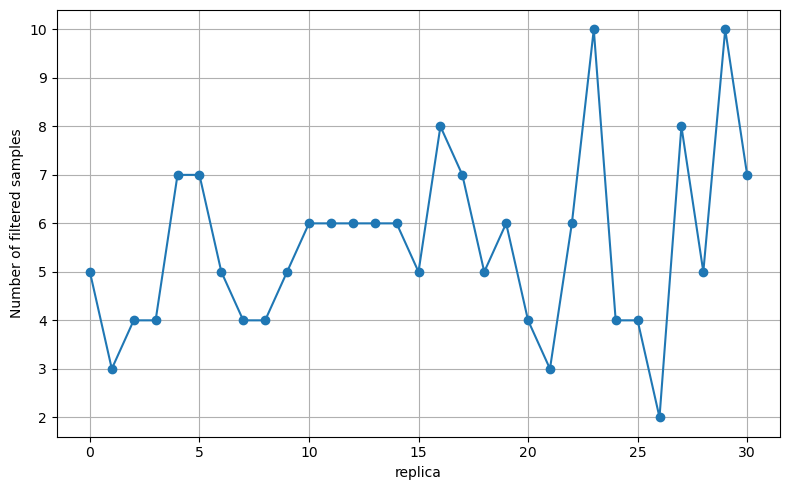

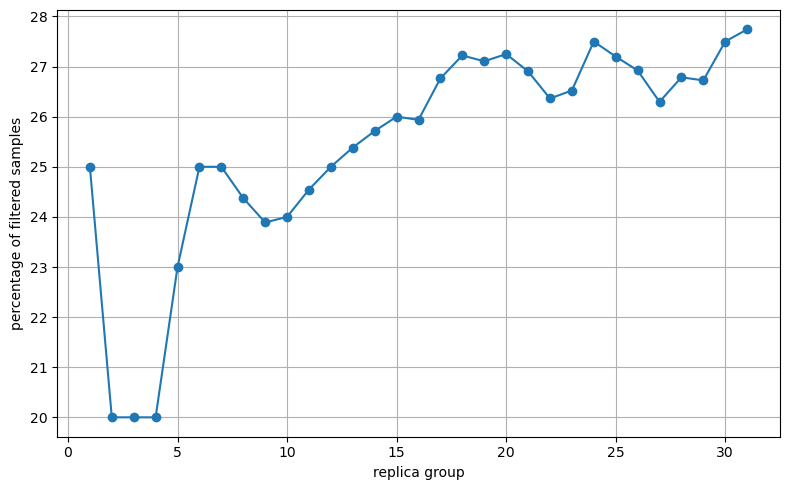

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([25.        , 20.        , 20.        , 20.        , 23.        ,
        25.        , 25.        , 24.375     , 23.88888889, 24.        ,
        24.54545455, 25.        , 25.38461538, 25.71428571, 26.        ,
        25.9375    , 26.76470588, 27.22222222, 27.10526316, 27.25      ,
        26.9047619 , 26.36363636, 26.52173913, 27.5       , 27.2       ,
        26.92307692, 26.2962963 , 26.78571429, 26.72413793, 27.5       ,
        27.74193548]))

In [134]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

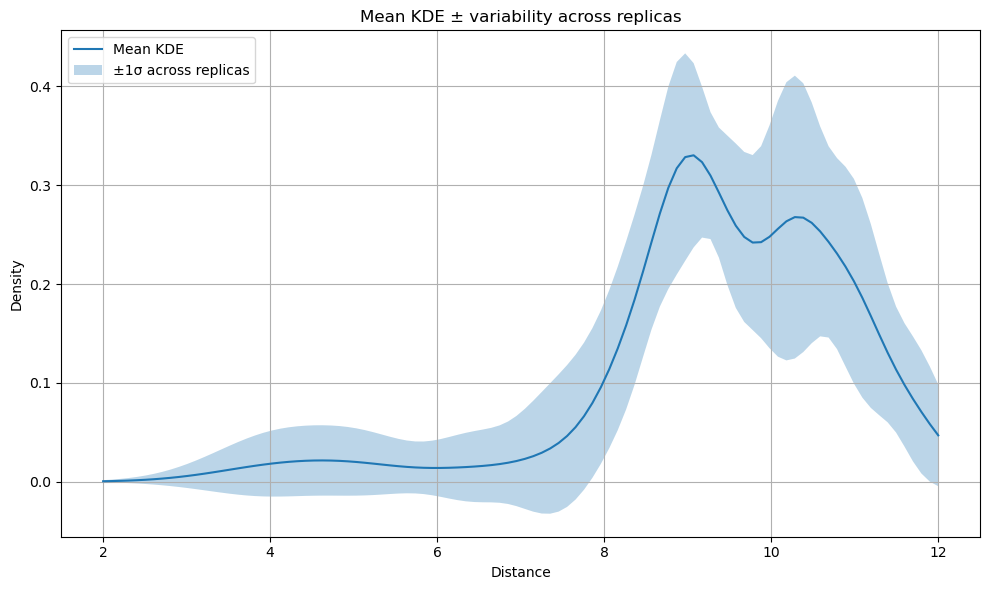

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [135]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|██████████████████████████████████████████████████████████████████| 4000/4000 [00:04<00:00, 994.96it/s]


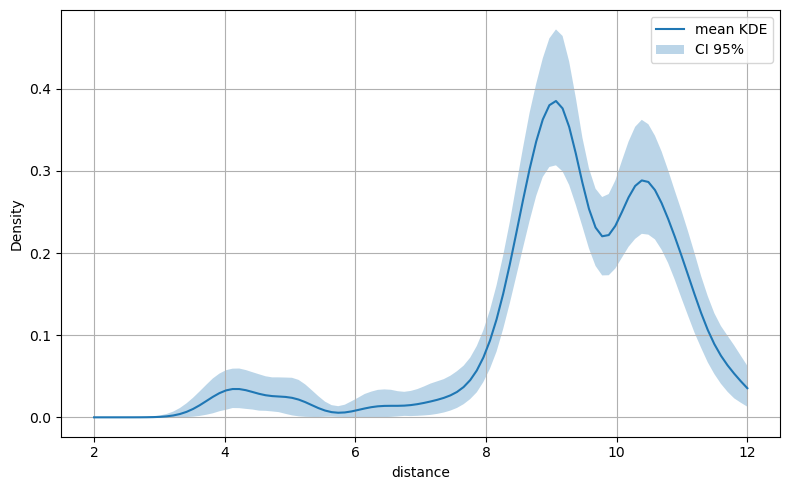

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,2.261011e-08,9.593603e-08,1.951946e-15,1.924255e-07
1,2.10101,7.866526e-08,2.885051e-07,2.614533e-14,6.544997e-07
2,2.20202,2.613512e-07,8.275504e-07,3.547671e-13,2.106957e-06
3,2.30303,8.278764e-07,2.263825e-06,3.969528e-12,6.321155e-06
4,2.40404,2.496091e-06,5.903133e-06,4.074435e-11,1.754991e-05
...,...,...,...,...,...
95,11.59596,7.501413e-02,1.807768e-02,4.081500e-02,1.111689e-01
96,11.69697,6.336367e-02,1.726955e-02,3.112939e-02,9.935132e-02
97,11.79798,5.326366e-02,1.614518e-02,2.316040e-02,8.765298e-02
98,11.89899,4.403527e-02,1.452043e-02,1.784225e-02,7.513715e-02


In [136]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-NGlu 

In [137]:
config = AnalysisConfig(
    root="NGlu-UDP/conf0",
    protein_pdb = "WTB.pdb",
    substrate_name="UDP-NGlu",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 44 and not protein",
    atom_sel_2="id 1269 and protein",
    obrms_exe=r""
)

In [138]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.07,0.94,0.9363,4.628,rep_0,0
1,2.0,-7.72,-0.30,0.8356,4.912,rep_0,0
2,3.0,-7.40,-0.18,0.8042,4.160,rep_0,0
3,4.0,-7.39,-1.01,0.7529,4.313,rep_0,0
4,5.0,-6.61,1.12,0.7063,4.609,rep_0,0


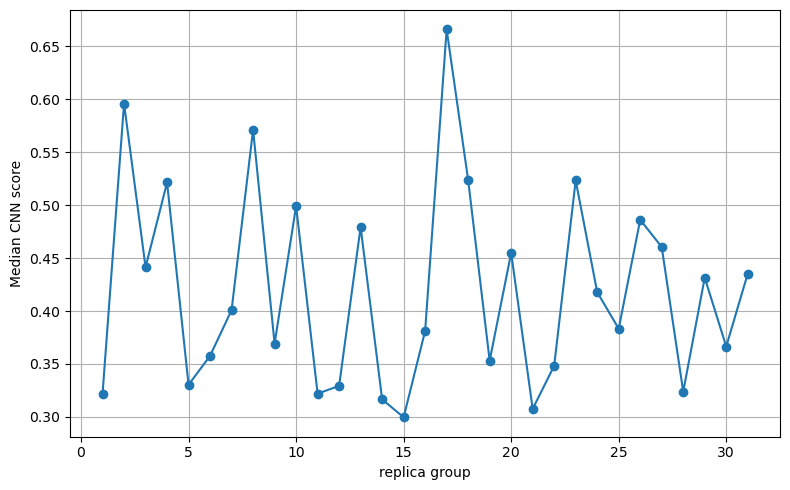

In [139]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [140]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

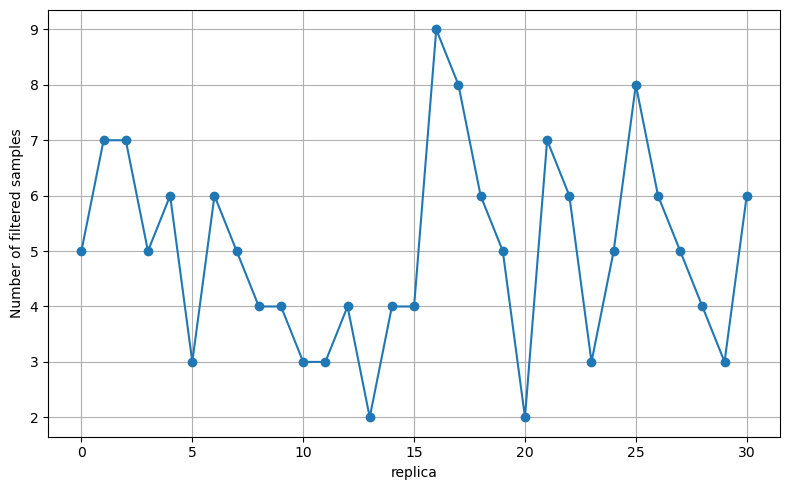

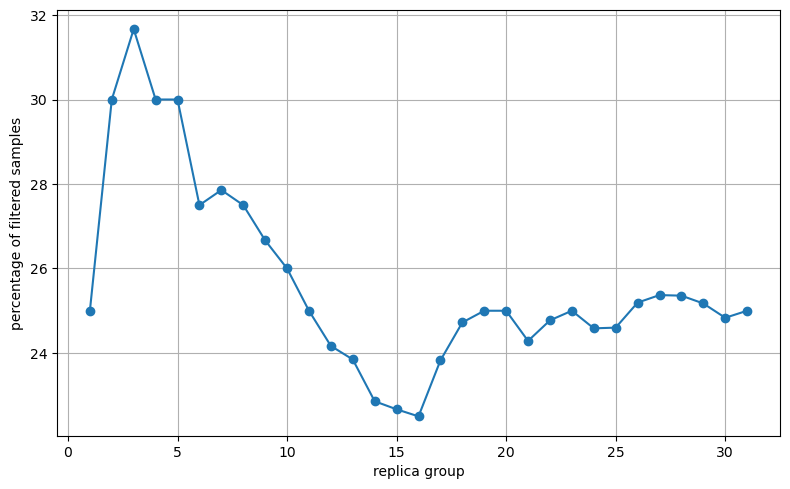

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([25.        , 30.        , 31.66666667, 30.        , 30.        ,
        27.5       , 27.85714286, 27.5       , 26.66666667, 26.        ,
        25.        , 24.16666667, 23.84615385, 22.85714286, 22.66666667,
        22.5       , 23.82352941, 24.72222222, 25.        , 25.        ,
        24.28571429, 24.77272727, 25.        , 24.58333333, 24.6       ,
        25.19230769, 25.37037037, 25.35714286, 25.17241379, 24.83333333,
        25.        ]))

In [141]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

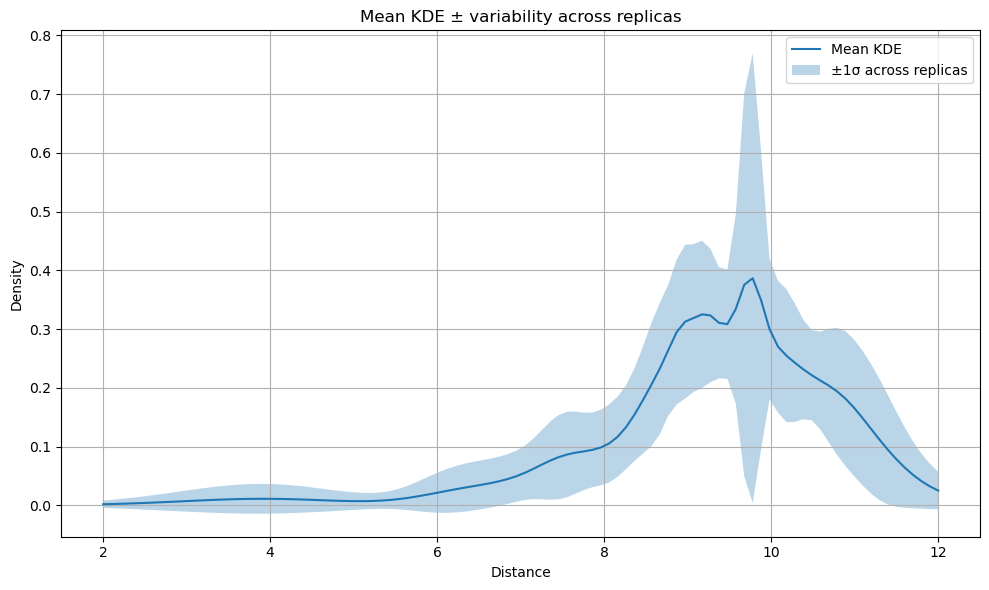

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [142]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|██████████████████████████████████████████████████████████████████| 4000/4000 [00:04<00:00, 969.50it/s]


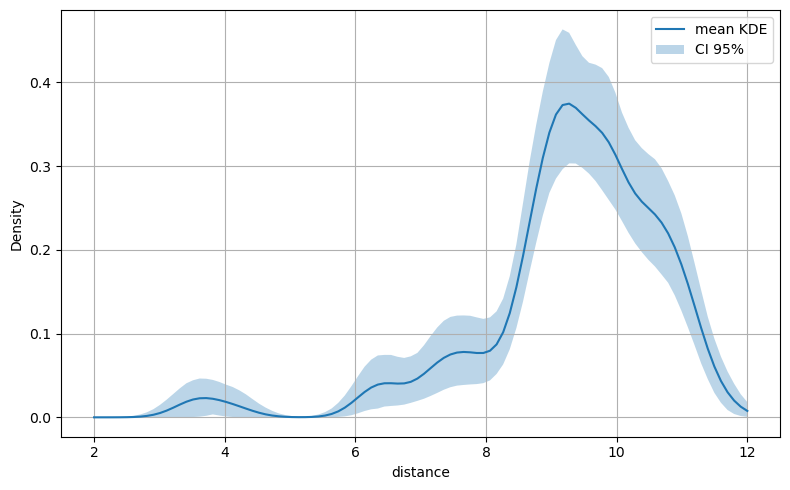

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,0.000001,0.000004,1.066081e-18,0.000009
1,2.10101,0.000004,0.000009,2.932085e-17,0.000026
2,2.20202,0.000010,0.000023,6.896412e-16,0.000071
3,2.30303,0.000028,0.000054,1.387170e-14,0.000178
4,2.40404,0.000073,0.000120,2.386140e-13,0.000415
...,...,...,...,...,...
95,11.59596,0.043426,0.014337,1.742581e-02,0.072482
96,11.69697,0.030029,0.011945,8.753804e-03,0.054754
97,11.79798,0.019991,0.009401,3.951453e-03,0.040097
98,11.89899,0.012706,0.006893,1.579375e-03,0.027585


In [143]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)

### UDP-NGla 

In [147]:
config = AnalysisConfig(
    root="NGla-UDP/conf0",
    protein_pdb = "WTB.pdb",
    substrate_name="UDP-NGla",
    ligand_file="WT1_glcA.mol2",
    ref_pdb="crystal_uridine.pdb",
    atom_sel_1="id 44 and not protein",
    atom_sel_2="id 1269 and protein",
    obrms_exe=r""
)

In [148]:
df = load_gnina_data(config)
display(df.head())

,mode,affinity,intramol,cnn_pose_score,cnn_affinity,replica,replica_num
0,1.0,-8.15,-2.58,0.9572,4.625,rep_0,0
1,2.0,-7.27,-2.28,0.9286,4.605,rep_0,0
2,3.0,-7.55,0.06,0.8874,5.011,rep_0,0
3,4.0,-8.33,-0.04,0.8837,4.402,rep_0,0
4,5.0,-7.03,-0.93,0.8066,4.642,rep_0,0


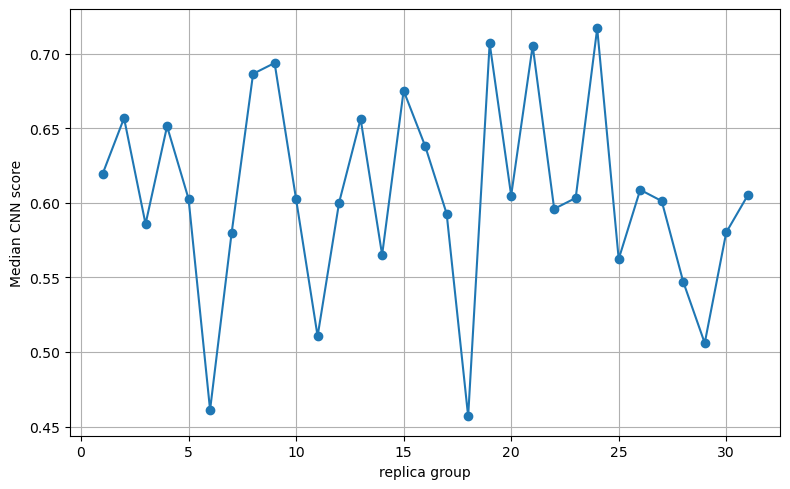

In [149]:
plot_median_cnn_score(df, group_size=1)
median_per_replica = save_median_per_replica(df, config)

In [150]:
dk_replicas, rmsds = analyze_all_replicas(df, config)
samples = count_filtered_samples(dk_replicas)

*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
C:\Users\davidelu\.conda\envs\davidelu-md\lib\site-packages\MDAnalysis\coordinates\DCD.py:463: UserWarning: No dimensions set for current frame, zeroed unitcell will be written
  warnings.warn(wmsg)
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Unable to open data file 'space-groups.txt'
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::Init
  Cannot initialize database 'space-groups.txt' which may cause further errors.
*** Open Babel Warning  in OpenBabel::OBGlobalDataBase::I

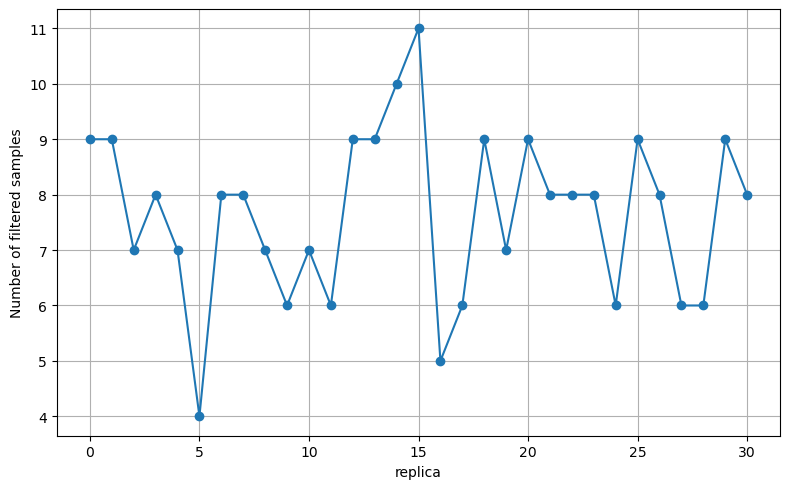

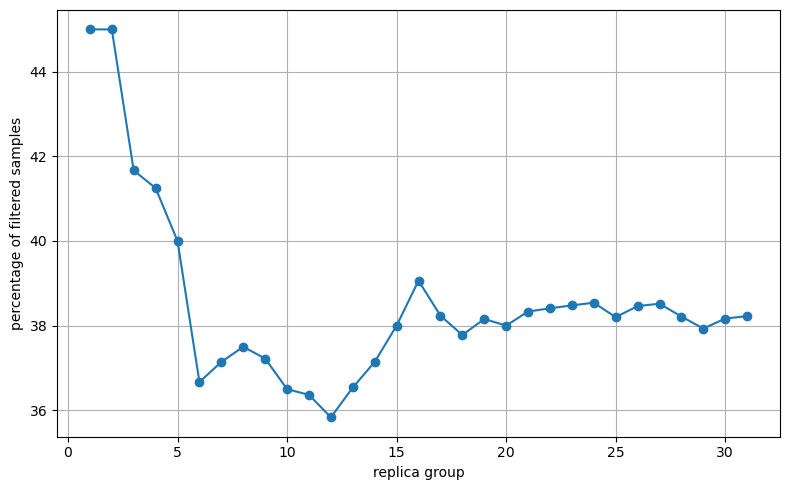

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([45.        , 45.        , 41.66666667, 41.25      , 40.        ,
        36.66666667, 37.14285714, 37.5       , 37.22222222, 36.5       ,
        36.36363636, 35.83333333, 36.53846154, 37.14285714, 38.        ,
        39.0625    , 38.23529412, 37.77777778, 38.15789474, 38.        ,
        38.33333333, 38.40909091, 38.47826087, 38.54166667, 38.2       ,
        38.46153846, 38.51851852, 38.21428571, 37.93103448, 38.16666667,
        38.22580645]))

In [151]:
plot_filtered_samples(samples)
plot_cumulative_percentage(samples, group_size=1, samples_per_replica=20)

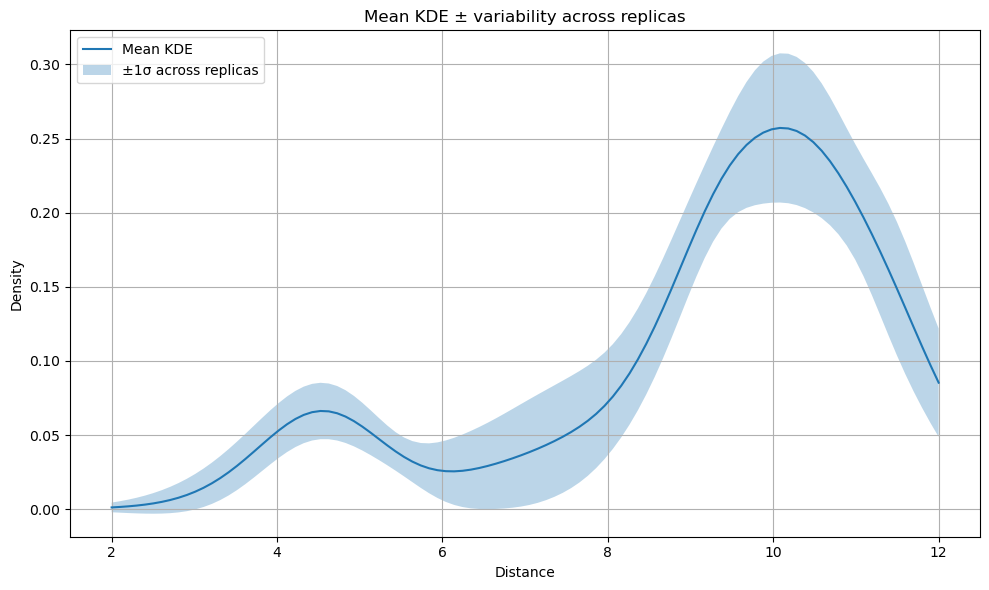

(array([ 2.        ,  2.1010101 ,  2.2020202 ,  2.3030303 ,  2.4040404 ,
         2.50505051,  2.60606061,  2.70707071,  2.80808081,  2.90909091,
         3.01010101,  3.11111111,  3.21212121,  3.31313131,  3.41414141,
         3.51515152,  3.61616162,  3.71717172,  3.81818182,  3.91919192,
         4.02020202,  4.12121212,  4.22222222,  4.32323232,  4.42424242,
         4.52525253,  4.62626263,  4.72727273,  4.82828283,  4.92929293,
         5.03030303,  5.13131313,  5.23232323,  5.33333333,  5.43434343,
         5.53535354,  5.63636364,  5.73737374,  5.83838384,  5.93939394,
         6.04040404,  6.14141414,  6.24242424,  6.34343434,  6.44444444,
         6.54545455,  6.64646465,  6.74747475,  6.84848485,  6.94949495,
         7.05050505,  7.15151515,  7.25252525,  7.35353535,  7.45454545,
         7.55555556,  7.65656566,  7.75757576,  7.85858586,  7.95959596,
         8.06060606,  8.16161616,  8.26262626,  8.36363636,  8.46464646,
         8.56565657,  8.66666667,  8.76767677,  8.8

In [152]:
plot_mean_kde_across_replicas(
    dk_replicas,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n,
    min_samples=config.kde_min_samples
)

Bootstrap KDE: 100%|██████████████████████████████████████████████████████████████████| 4000/4000 [00:06<00:00, 615.22it/s]


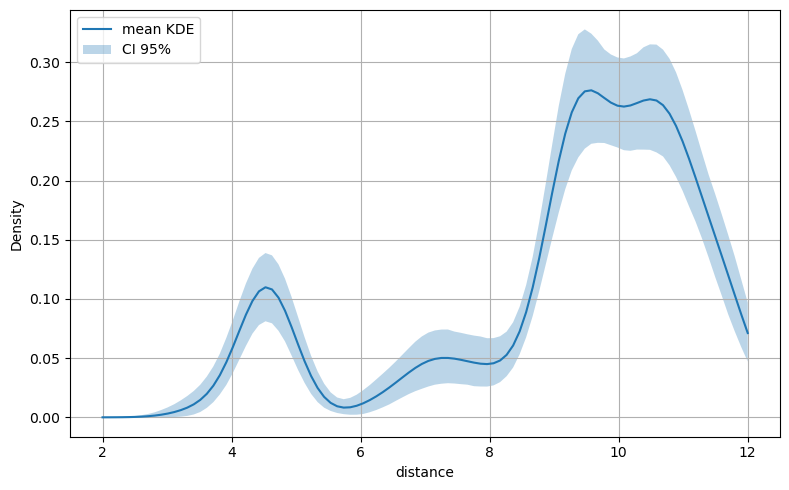

,x,kde_mean,kde_std,ci_lower,ci_upper
0,2.00000,0.000013,0.000015,5.380165e-10,0.000055
1,2.10101,0.000027,0.000031,2.380978e-09,0.000112
2,2.20202,0.000055,0.000059,9.912659e-09,0.000213
3,2.30303,0.000107,0.000108,3.882389e-08,0.000385
4,2.40404,0.000198,0.000190,1.431247e-07,0.000684
...,...,...,...,...,...
95,11.59596,0.136583,0.017421,1.030213e-01,0.171699
96,11.69697,0.120063,0.016857,8.700308e-02,0.154177
97,11.79798,0.103470,0.015868,7.272472e-02,0.136073
98,11.89899,0.087037,0.014430,5.937705e-02,0.116498


In [153]:
bootstrap_kde(
    dk_replicas,
    output_csv=str(Path(config.root) / f"bootstrap_kde_distribution_{config.substrate_name}.csv"),
    n_bootstrap=4000,
    confidence_level=95,
    x_min=config.x_grid_min,
    x_max=config.x_grid_max,
    n_points=config.x_grid_n
)